## Cell 1 · 경로 자동 감지


In [1]:
import sys, os, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

_CANDIDATE_ROOTS = [
    r"C:\Users\Hoyoung_Park\PyCharmMiscProject\stock_forecast",
    r"C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy",
]

def _setup_path() -> str:
    try:
        start = Path(__file__).resolve().parent
    except NameError:
        start = Path.cwd()
    for p in [start] + list(start.parents):
        if (p / "DATA").is_dir():
            root = str(p)
            if root not in sys.path:
                sys.path.insert(0, root)
            print(f"[PATH] root 자동 감지 : {root}")
            return root
    for cand in _CANDIDATE_ROOTS:
        if os.path.isdir(cand) and os.path.isdir(os.path.join(cand, "DATA")):
            if cand not in sys.path:
                sys.path.insert(0, cand)
            print(f"[PATH] root 후보 경로 : {cand}")
            return cand
    raise EnvironmentError(
        "DATA 폴더를 찾을 수 없습니다. _CANDIDATE_ROOTS 를 환경에 맞게 수정하세요."
    )

_ROOT = _setup_path()
print(f"[확인] 프로젝트 루트 : {_ROOT}")
print(f"[확인] DATA 경로    : {os.path.join(_ROOT, 'DATA')}")


[PATH] root 자동 감지 : C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy
[확인] 프로젝트 루트 : C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy
[확인] DATA 경로    : C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy\DATA


## Cell 2 · Import & 설정 상수

> **여기만 수정하면 됩니다**:
> - `TICKER_START / TICKER_END / SKIP_DONE`
> - `ERP_METHOD` (`'damodaran_floor'` or `'kospi_geo_10y'`)
> - `MIN_REVENUE_QUARTERS` (기본 24분기 = 6년)

> **v2 신규 상수**:
> - `G_FLOOR_MIN = -0.20`  Phase 2 음수 g₀ 하한 (사이클릭 침체 -20% 까지 허용, US v9.2 패치)
> - `G_CEIL = 0.50`         Phase 2 g 상한


In [2]:
# ── 표준 라이브러리 ──────────────────────────────────────────────
import gc, math, time, traceback, warnings
from datetime import datetime, date, timedelta
from typing import Optional, Dict, Any, List, Tuple

# ── 외부 라이브러리 ──────────────────────────────────────────────
import numpy as np
import pandas as pd
import pymysql
from scipy import stats
from IPython.display import display
import matplotlib
matplotlib.rcParams["axes.unicode_minus"] = False
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sqlalchemy import text

# ── 내부 모듈 ────────────────────────────────────────────────────
from DATA.config import get_db_info, get_engine
from DATA.KEYS import KEYS
from DATA.korea_valuation_helpers import (
    setup_project_path, to_dg_ticker, to_price_ticker, get_pymysql_conn,
    DG_ITEM_CODES, get_item_code,
    load_korea_financials_wide, load_korea_revenue_forecast,
    load_korea_marketcap_latest, load_korea_price_series, load_current_price,
    load_kospi_series, get_risk_free_rate, compute_beta_10y,
    estimate_market_return, get_universe_with_min_history,
    DataQualityReport, save_quality_report_to_db, get_evaluation_history,
)
from DATA.universal_ts_forecast_function_v2 import (
    forecast_sarima, forecast_ets, forecast_theta,
    infer_freq_alias, seasonal_periods_from_freq, clear_memory,
)

def log(tag: str, msg: str):
    ts = datetime.now().strftime("%H:%M:%S")
    print(f"[{ts}][{tag}] {msg}", flush=True)

# ══════════════════════════════════════════════════════════════════
#  설정 상수 — 여기만 수정하세요
# ══════════════════════════════════════════════════════════════════

# DB 테이블
TABLE_FS         = "korea_fs_data_from_DG"
TABLE_FORECAST   = "korea_revenue_forecast_result"
TABLE_MARKETCAP  = "ks_listed_company_daily_marketcap"
TABLE_PRICE      = "KSE_Price"
TABLE_RESULT     = "korea_fcff_dcf_valuation"
TABLE_QUALITY    = "korea_valuation_quality_log"

# 모델 파라미터
FORECAST_HORIZON     = 8        # 예측 분기 수 (2년)
MIN_HISTORY          = 16       # OPM 회귀 최소 분기 수
MIN_REVENUE_QUARTERS = 24       # universe 필터: 최소 24분기(6년) 매출 보유
WINSORIZE_LIMITS     = (0.05, 0.95)
GDP_GROWTH           = 0.04    # 한국 장기 GDP 성장률 추정 (terminal cap)

# ★ v2 신규: Phase 2 g₀ 범위 (US v9.2 패치)
G_FLOOR_MIN          = -0.20    # Phase 2 음수 g₀ 하한 (사이클릭 침체)
G_CEIL               = 0.50     # Phase 2 g 상한

# OLS fallback 기준
OLS_MIN_R2           = 0.30
OLS_MIN_SAMPLES      = 16

# WACC 관련
ERP_METHOD           = "damodaran_floor"  # 'damodaran_floor' | 'kospi_geo_10y' | 'kospi_geo_no_floor'
DAMODARAN_ERP_KR     = 0.07               # Damodaran 한국 ERP (호영님 기본)
GEO_FLOOR            = 0.07               # KOSPI geo 사용 시 E(Rm) floor
RF_FALLBACK          = 0.035              # BOK API 실패 시 fallback Rf
RD_DEFAULT           = 0.045              # 부채비용 기본값
WACC_FLOOR           = 0.05
WACC_CAP             = 0.20

# Net Debt / Total Debt 합산 항목 (BS 컬럼 키)
DEBT_KEYS = ["short_term_debt", "current_lt_debt", "bonds",
             "long_term_debt", "lease_liab"]
CASH_KEYS = ["cash", "short_term_invest"]

# 단위 환산
MARKETCAP_UNIT_MULTIPLIER = 1_000_000  # 백만원 → 원
FS_UNIT_MULTIPLIER        = 1_000      # 천원 → 원

# 배치 범위
TICKER_START = 0
TICKER_END   = 9999
SKIP_DONE    = False

# 체크포인트
CHECKPOINT_DIR = "_korea_fcff_checkpoint"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
DONE_PATH = os.path.join(CHECKPOINT_DIR, "done_tickers.txt")
FAIL_PATH = os.path.join(CHECKPOINT_DIR, "failed_tickers.txt")

db_info = get_db_info()
engine  = get_engine(db_info)

print(f"[OK] Import 완료")
print(f"[설정] FORECAST_HORIZON={FORECAST_HORIZON}Q  ERP_METHOD={ERP_METHOD}")
print(f"[설정] MIN_REVENUE_QUARTERS={MIN_REVENUE_QUARTERS}  GDP_GROWTH={GDP_GROWTH}")
print(f"[설정] WACC 범위 [{WACC_FLOOR:.0%}, {WACC_CAP:.0%}]")
print(f"[설정] Phase2 g 범위 [{G_FLOOR_MIN:.0%}, {G_CEIL:.0%}]   ★ v2 신규")


[OK] Import 완료
[설정] FORECAST_HORIZON=8Q  ERP_METHOD=damodaran_floor
[설정] MIN_REVENUE_QUARTERS=24  GDP_GROWTH=0.04
[설정] WACC 범위 [5%, 20%]
[설정] Phase2 g 범위 [-20%, 50%]   ★ v2 신규


## Cell 3 · DB 연결 & 결과 테이블 초기화

`korea_fcff_dcf_valuation` 테이블 (없으면 생성):
- PK = (ticker, date, quarter) → 같은 종목의 같은 평가일자 + 같은 분기는 갱신
- 평가일자(date)가 다르면 별도 row → 시계열 추적 가능


In [3]:
# ── 결과 테이블 생성 (없으면) ─────────────────────────────────
CREATE_SQL = f'''
CREATE TABLE IF NOT EXISTS `{TABLE_RESULT}` (
  `id`                BIGINT      NOT NULL AUTO_INCREMENT,
  `date`              DATE        NOT NULL COMMENT '평가 실행일',
  `ticker`            VARCHAR(20) NOT NULL COMMENT 'A005930 형식',
  `quarter`           VARCHAR(10)          COMMENT 'e.g. 2026Q1',
  `sales_actual`      DOUBLE               COMMENT '과거 Sales (원)',
  `sales_forecast`    DOUBLE               COMMENT '예측 Sales (원)',
  `opm_forecast`      DOUBLE,
  `ebit`              DOUBLE,
  `tax_rate`          DOUBLE,
  `nopat`             DOUBLE,
  `da`                DOUBLE,
  `capex`             DOUBLE,
  `nwc`               DOUBLE,
  `delta_nwc`         DOUBLE,
  `fcff`              DOUBLE,
  `roic`              DOUBLE,
  `reinvestment_rate` DOUBLE,
  `g_terminal`        DOUBLE,
  `discount_rate`     DOUBLE COMMENT 'WACC',
  `wacc_re`           DOUBLE COMMENT 'Cost of Equity',
  `wacc_rd`           DOUBLE COMMENT 'Cost of Debt',
  `beta_raw`          DOUBLE,
  `beta_blume`        DOUBLE,
  `enterprise_value`  DOUBLE,
  `net_debt`          DOUBLE,
  `equity_value`      DOUBLE,
  `shares`            DOUBLE,
  `target_price`      DOUBLE,
  `current_price`     DOUBLE,
  `upside_pct`        DOUBLE,
  `moat_label`        VARCHAR(30),
  `eva_spread`        DOUBLE,
  `revenue_quarters`  INT COMMENT '사용된 매출 분기 수',
  `forecast_model`    VARCHAR(20) COMMENT 'Sales 예측 모델명',
  `forecast_date`     DATE COMMENT '매출 예측 실행일',
  `created_at`        DATETIME    DEFAULT CURRENT_TIMESTAMP,
  PRIMARY KEY (`id`),
  UNIQUE KEY uq_main (`ticker`, `date`, `quarter`),
  INDEX idx_ticker (`ticker`),
  INDEX idx_date   (`date`)
) ENGINE=InnoDB DEFAULT CHARSET=utf8mb4
'''

conn = get_pymysql_conn(db_info)
try:
    with conn.cursor() as cur:
        cur.execute(CREATE_SQL)
    conn.commit()
    log("DB", f"테이블 준비 완료: {TABLE_RESULT}")
finally:
    conn.close()

# 연결 테스트
try:
    with engine.connect() as c:
        c.execute(text("SELECT 1"))
    log("DB", f"연결 성공 host={db_info.get('host')} port={db_info.get('port')}")
except Exception as e:
    log("DB", f"연결 실패: {e}")

# Universe 미리 조회
universe_df = get_universe_with_min_history(
    db_info, min_quarters=MIN_REVENUE_QUARTERS, require_consecutive=False
)
KOREA_TICKER_LIST = universe_df["ticker"].tolist()
print(f"\n[Universe] 매출 ≥{MIN_REVENUE_QUARTERS}분기 종목: {len(KOREA_TICKER_LIST):,}개")
print(f"  최장 보유: {universe_df['n_quarters'].max()}분기")
print(f"  평균 결측 분기: {universe_df['gap_count'].mean():.1f}")
display(universe_df.head(10))


[23:56:17][DB] 테이블 준비 완료: korea_fcff_dcf_valuation
[23:56:17][DB] 연결 성공 host=192.168.0.230 port=3307

[Universe] 매출 ≥24분기 종목: 1,267개
  최장 보유: 66분기
  평균 결측 분기: 0.3


,ticker,n_quarters,first_date,last_date,gap_count
0,A002320,66,2009-12-30,2026-03-31,0
1,A005930,66,2009-12-30,2026-03-31,0
2,A039840,66,2009-12-30,2026-03-31,0
3,A052400,66,2009-12-30,2026-03-31,0
4,A046890,66,2009-12-30,2026-03-31,0
5,A066570,66,2009-12-30,2026-03-31,0
6,A006040,65,2009-12-30,2025-12-30,0
7,A006120,65,2009-12-30,2025-12-30,0
8,A006340,65,2009-12-30,2025-12-30,0
9,A006400,65,2009-12-30,2025-12-30,0


## Cell 4 · 시장 파라미터 (Rf, KOSPI, E(Rm)) — 1회 계산 후 캐싱

배치 시작 전에 **시장 공통 파라미터** 계산해서 모든 종목이 공유:
- `RF`         : BOK API → 10Y 국고채 (실시간)
- `KOSPI_PX`   : FDR → KOSPI 종합지수 (베타·E(Rm) 계산용)
- `E_Rm`, `ERP`: Damodaran 또는 KOSPI geo 10y


In [4]:
# 1. Risk-free rate (BOK API)
RF, RF_SOURCE = get_risk_free_rate(KEYS["BOK"], fallback_rate=RF_FALLBACK)
log("MKT", f"Rf = {RF:.4%}  (source: {RF_SOURCE})")

# 2. KOSPI 시계열 (12년치 → 베타·E(Rm) 모두 사용)
KOSPI_PX = load_kospi_series(start_date=(datetime.today() - timedelta(days=365*12)).strftime("%Y-%m-%d"))
log("MKT", f"KOSPI {len(KOSPI_PX):,}거래일  ({KOSPI_PX.index.min().date()} ~ {KOSPI_PX.index.max().date()})")
log("MKT", f"  현재 KOSPI = {KOSPI_PX.iloc[-1]:,.2f}")

# 3. E(Rm) 추정
mkt = estimate_market_return(
    method=ERP_METHOD, rf=RF, kospi_series=KOSPI_PX,
    years=10, damodaran_erp_kr=DAMODARAN_ERP_KR, geo_floor=GEO_FLOOR,
)
E_RM = mkt["e_rm"]
ERP  = mkt["erp"]
log("MKT", f"E(Rm) = {E_RM:.4%}  ERP = {ERP:.4%}")
log("MKT", f"  → {mkt['note']}")
if mkt["kospi_geo"] is not None:
    log("MKT", f"  (참고) KOSPI 10년 기하평균 = {mkt['kospi_geo']:.4%}")

print()
print("=" * 60)
print(f"  Rf  = {RF:>7.3%}    (BOK 10Y 국고채)")
print(f"  ERP = {ERP:>7.3%}    (방식: {ERP_METHOD})")
print(f"  E(Rm) = {E_RM:>7.3%}")
print("=" * 60)


[23:56:28][MKT] Rf = 4.0440%  (source: BOK_2026-05-13)
[KOSPI] try source=fdr (2014-05-16 ~ 2026-05-13) ... FAIL (FDR 실패 (재시도 3회): LOGOUT)
[KOSPI] try source=pykrx (2014-05-16 ~ 2026-05-13) ... FAIL ('지수명')
[KOSPI] try source=yfinance (2014-05-16 ~ 2026-05-13) ... OK  2,937거래일
[23:56:41][MKT] KOSPI 2,937거래일  (2014-05-16 ~ 2026-05-12)
[23:56:41][MKT]   현재 KOSPI = 7,643.15
[23:56:41][MKT] E(Rm) = 11.0440%  ERP = 7.0000%
[23:56:41][MKT]   → Damodaran 한국 ERP 7.0% 적용
[23:56:41][MKT]   (참고) KOSPI 10년 기하평균 = 14.4785%

  Rf  =  4.044%    (BOK 10Y 국고채)
  ERP =  7.000%    (방식: damodaran_floor)
  E(Rm) = 11.044%


## Cell 5 · KoreaDCFModel **v2** 클래스 (★ 핵심 변경)

US v11 `DCFModel` 의 한국화 + **v8 + v9.2 패치 적용**.

### v1 → v2 클래스 단위 변경 요약

| 메서드 | v1 (기존) | **v2 (개선)** | 학술/실무 근거 |
|--------|----------|---------------|------------|
| `_compute_bs_nwc_series` *(신규)* | — | **NWC 필드 alias 매핑 + sanity check** | US v8 — silent 0 대체 방지 |
| `estimate_nwc_coef` | NWC 산식만 계산 | **+ `_last_actual_nwc` 저장 → ΔNWC 시드값 일관성 진단** | US v8 |
| `compute_fcff` | `prev_nwc=None` → 첫 분기 ΔNWC=0 | **`prev_nwc = γ × last_actual_sales` 시드** | US v8 — 첫 분기 FCFF 과대계상 제거 |
| `_compute_historical_fcff` | 동일 버그 | **`prev_nwc = γ × first_sales` 시드** | US v8 |
| `_estimate_phase2_growth` | 단일 8Q-CAGR + AR(1) | **다중 fallback 체인 + g0_hist+g0_fc 결합 + ρ OLS 보정** | US v9.2 — 사이클릭 종목 과대평가 방지 |
| AR(1) clip 하한 | `G_TERM`(0.025) | **`G_FLOOR_MIN`(-0.20)** | US v9.2 |

### 한국 특화 (v1 그대로 유지)
- 데이터 소스: FMP API → DataGuide DB
- 베타: 사전계산 X → KSE_Price + KOSPI 일별수익률 10년 회귀, Blume 조정
- NWC: 한국 BS 보완 산식 `(Receivables + Inventories) - (ST debts)`
- DataQualityReport 로 모든 fallback 추적


[OK] KoreaDCFModel v2 클래스 & process_one_ticker_kr 정의 완료

[테스트] A002900 단일 실행 ...
[23:57:36][A002900] Sales actual=65Q forecast=8Q model=Ensemble created_at=2026-04-21 00:00:00
[23:57:36][A002900] FS wide  shape=(67, 35)  기간=2009-12-31 ~ 2026-06-30
[메모리] forecast_sarima 실행 전: 483.71 MB
[메모리] find_best_sarima_params 실행 전: 483.72 MB
[메모리] find_best_sarima_params 실행 후: 485.93 MB (변화: +2.21 MB)
[메모리] forecast_sarima 실행 후: 485.97 MB (변화: +2.26 MB)
[메모리] forecast_ets 실행 전: 485.97 MB
[메모리] forecast_ets 실행 후: 486.22 MB (변화: +0.25 MB)
[메모리] forecast_theta 실행 전: 486.22 MB
[메모리] forecast_theta 실행 후: 486.38 MB (변화: +0.16 MB)
[23:57:47][A002900] [NWC seed] γ×sales=154.4B vs 실측=0.0B 괴리 15443210645556.3%
[23:57:52][A002900] β_raw=0.938 β_blume=0.959  Re=10.7552%  (n=2449, R²=0.10)
[23:57:56][A002900] WACC=10.7552%  Re=10.7552% Rd=1.0540% tax=24.1828%  E/V=100.00% D/V=0.00%  E=0.29조 D=0.00조
[23:57:56][A002900] EVA: ROIC=9.68%  WACC=10.76%  spread=-1.08%  n_pos(20Q)=6/20
[23:57:56][A002900] Moat: [No mo

,field,status,n_obs,value,r2,note
0,revenue_actual,ok,65,NaN,NaN,
1,revenue_forecast,ok,8,NaN,NaN,"model=Ensemble, created_at=2026-04-21 00:00:00"
2,operating_income,ok,65,NaN,NaN,
3,tax_rate,ok,44,0.241828,NaN,
4,opm_forecast,ok,65,NaN,NaN,"models=['SARIMA', 'ETS', 'Theta']"
5,da,ok,65,0.014938,0.418697,"OLS cols=['da_cf', 'intangible_amort_cf']"
6,capex,fallback_median,65,0.025138,0.082900,"OLS R²=0.08 → median, cols=['capex_tangible', ..."
7,nwc,ok,65,0.712098,0.763503,(Recv+Inv) - (ST debts) ratio
8,beta,ok,2449,0.958739,0.095298,β_raw=0.938 → blume=0.959
9,tax_rate,ok,44,0.241828,NaN,


[메모리] forecast_sarima 실행 전: 487.26 MB
[메모리] find_best_sarima_params 실행 전: 487.26 MB
[메모리] find_best_sarima_params 실행 후: 487.26 MB (변화: +0.00 MB)
[메모리] forecast_sarima 실행 후: 487.26 MB (변화: +0.00 MB)
[메모리] forecast_ets 실행 전: 487.26 MB
[메모리] forecast_ets 실행 후: 487.26 MB (변화: +0.00 MB)
[메모리] forecast_theta 실행 전: 487.26 MB
[메모리] forecast_theta 실행 후: 487.26 MB (변화: +0.00 MB)


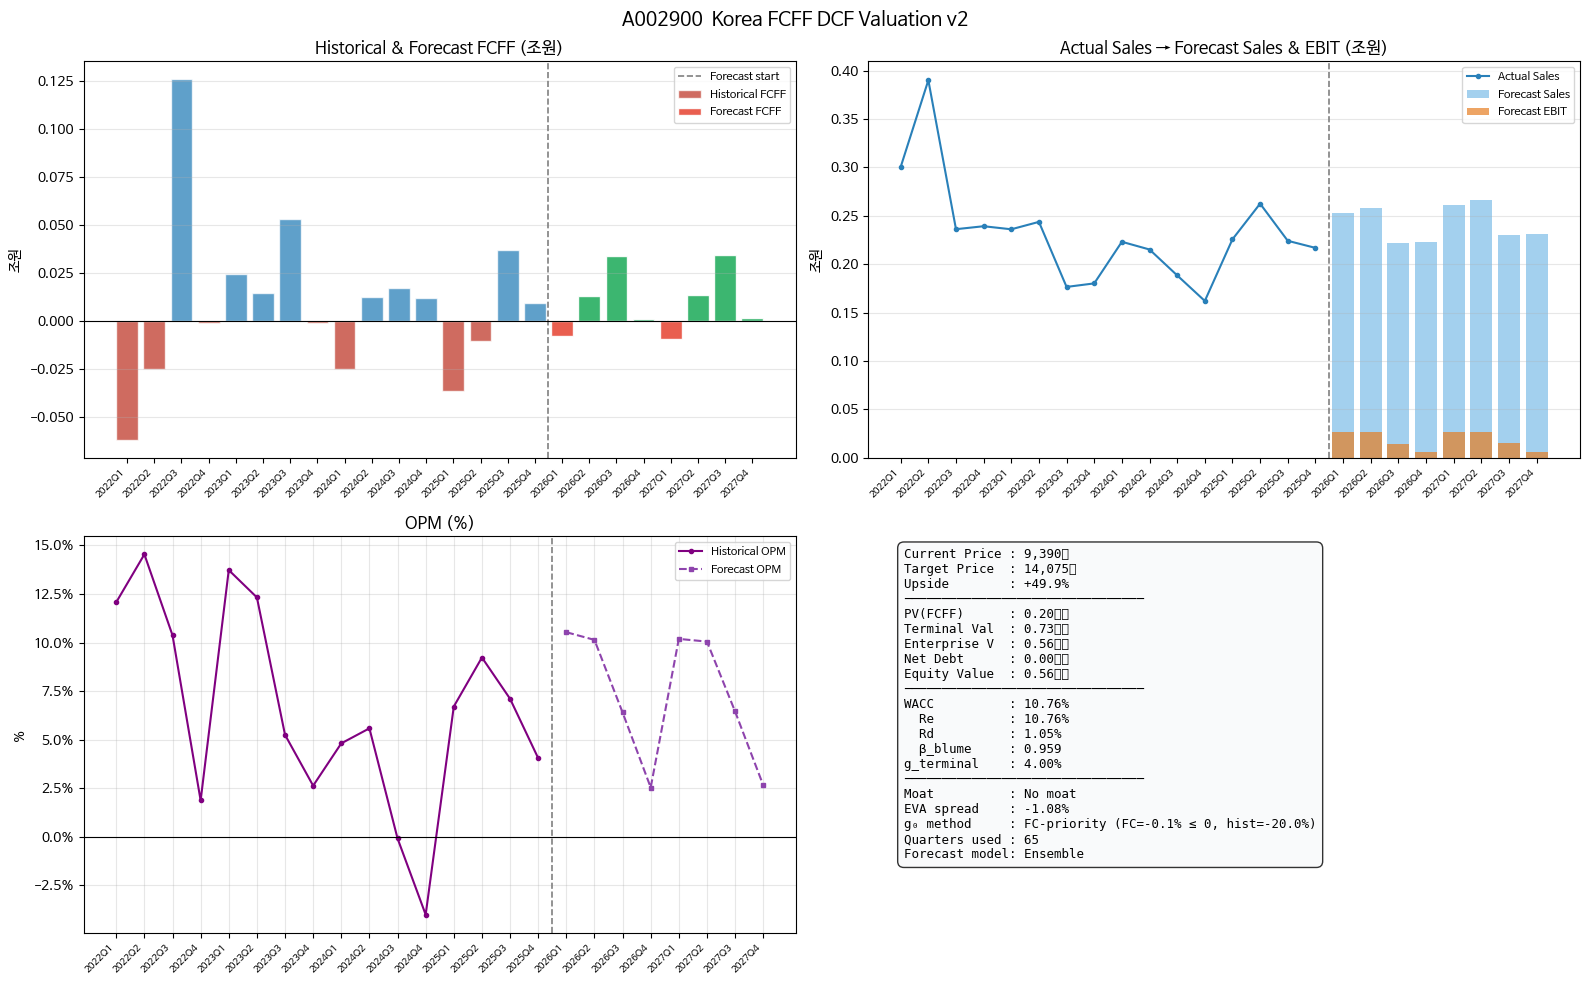

In [5]:
# ═══════════════════════════════════════════════════════════════
#  KoreaDCFModel v2  —  한국 주식 Sales-driven FCFF DCF
#  (US v11 v8 + v9.2 패치 이식)
# ═══════════════════════════════════════════════════════════════

class KoreaDCFModel:
    """
    한국 기업 FCFF DCF Valuation Model — v2.

    사용 흐름:
        m = KoreaDCFModel(ticker="A005930", engine=engine, db_info=db_info,
                          rf=RF, e_rm=E_RM, kospi_series=KOSPI_PX, verbose=True)
        m.run()
        m.save_to_db("2026-04-21")
        m.plot()

    v1 → v2 변경사항:
      [v8 패치]
        - NWC_FIELD_ALIASES 매핑 + _compute_bs_nwc_series()
        - estimate_nwc_coef() 가 _last_actual_nwc 저장
        - compute_fcff() prev_nwc 를 γ × last_actual_sales 로 시드
        - _compute_historical_fcff() 첫 분기 prev_nwc 를 γ × first_sales 로 시드
      [v9.2 패치]
        - _estimate_phase2_growth(): 다중 fallback 체인
          · Method 1: 8Q-CAGR (양수 케이스만)
          · Method 2: 12Q-TTM rolling (★ 신규, 부호 반전 명시 처리)
          · Method 3: Forecast yr1/yr2 (★ 신규, g0_fc 로 항상 계산)
        - g0_hist + g0_fc 결합 로직 (min, forecast 우선, 부호 불일치)
        - 음수 g₀ 허용 (G_FLOOR_MIN = -0.20)
        - ρ OLS 보정 (음수 annual 도 회귀 포함)
        - AR(1) clip 하한 G_FLOOR_MIN 으로 완화

    한국 특화 (v1 동일):
      - FMP API 호출 없음 → 모두 DB 조회
      - 자체 베타 계산 (KSE_Price + KOSPI 일별수익률 10년 회귀, Blume)
      - NWC ≈ Receivables + Inventories - Short-term debts  (한국 BS 보완)
      - DataQualityReport 로 모든 fallback 추적
    """

    # ─────────────────────────────────────────────────────────────
    # ★ v8 패치: NWC 필드 alias 매핑 (silent 0 대체 방지)
    #
    # 한국 DataGuide 의 정규화된 컬럼명을 표준 키 → 후보 컬럼들로 매핑.
    # 핵심 컬럼이 없거나 전부 0 이면 verbose 모드에서 경고 출력.
    # ─────────────────────────────────────────────────────────────
    NWC_FIELD_ALIASES = {
        # 자산 측
        "receivables":      ["receivables", "trade_receivables",
                             "accounts_receivable"],
        "inventories":      ["inventories", "inventory"],
        # 부채 측 (단기성)
        "short_term_debt":  ["short_term_debt", "short_term_borrowings"],
        "current_lt_debt":  ["current_lt_debt", "current_portion_of_lt_debt"],
        "lease_liab":       ["lease_liab", "lease_liabilities", "lease_liability"],
    }

    def __init__(self, ticker, engine, db_info,
                 rf, e_rm, kospi_series,
                 forecast_horizon=FORECAST_HORIZON,
                 min_history=MIN_HISTORY,
                 gdp_growth=GDP_GROWTH,
                 verbose=False):
        self.ticker_dg     = to_dg_ticker(ticker)
        self.ticker_price  = to_price_ticker(ticker)
        self.engine        = engine
        self.db_info       = db_info
        self.rf            = rf
        self.e_rm          = e_rm
        self.erp           = e_rm - rf
        self.kospi         = kospi_series
        self.horizon       = forecast_horizon
        self.min_history   = min_history
        self.gdp_growth    = gdp_growth
        self.verbose       = verbose

        # 데이터 저장소
        self._sales_actual:   Optional[pd.Series]    = None
        self._sales_forecast: Optional[pd.Series]    = None
        self._used_model:     str                    = ""
        self._forecast_date:  Optional[date]         = None
        self._fs_wide:        Optional[pd.DataFrame] = None
        self._stock_data:     Optional[pd.DataFrame] = None
        self._fcff_history:   Optional[pd.Series]    = None
        self._beta_info:      Optional[Dict]         = None
        self._mkt_cap:        Optional[float]        = None
        self._current_price:  Optional[float]        = None
        self._last_actual_nwc: Optional[float]       = None  # ★ v8

        self.result_df: Optional[pd.DataFrame]       = None
        self.valuation: Optional[Dict]               = None
        self.report = DataQualityReport(ticker=self.ticker_dg)

    # ─────────────────────────────────────────────────────────
    # 1. 데이터 로드
    # ─────────────────────────────────────────────────────────

    def load_sales(self):
        """매출 actual + forecast 로드. 핵심항목이라 결측 시 즉시 raise."""
        # Actual
        wide = load_korea_financials_wide(
            self.ticker_dg, self.db_info, table_name=TABLE_FS,
            item_keys=["revenue"], fillna_zero=False,
        )
        actual = wide["revenue"].dropna() * FS_UNIT_MULTIPLIER  # 천원 → 원
        if actual.empty:
            self.report.add("revenue_actual", "missing", n_obs=0,
                            note="korea_fs_data_from_DG에 매출 데이터 없음")
            raise ValueError(f"[{self.ticker_dg}] Sales actual 데이터 없음")

        if len(actual) < MIN_REVENUE_QUARTERS:
            self.report.add("revenue_actual", "missing", n_obs=len(actual),
                            note=f"매출 {len(actual)}분기 < 최소 {MIN_REVENUE_QUARTERS}")
            raise ValueError(
                f"[{self.ticker_dg}] 매출 {len(actual)}분기 < 최소 {MIN_REVENUE_QUARTERS}분기"
            )
        self.report.add("revenue_actual", "ok", n_obs=len(actual))

        # Forecast
        forecast, model_name, ca = load_korea_revenue_forecast(
            self.ticker_dg, self.db_info, table_name=TABLE_FORECAST,
            horizon=self.horizon,
        )
        if forecast.empty:
            self.report.add("revenue_forecast", "missing", n_obs=0,
                            note="korea_revenue_forecast_result에 예측 없음")
            raise ValueError(
                f"[{self.ticker_dg}] 매출 forecast 없음 — Korea_revenue_forecast 먼저 실행"
            )
        forecast = forecast * FS_UNIT_MULTIPLIER  # 천원 → 원
        self.report.add("revenue_forecast", "ok", n_obs=len(forecast),
                        note=f"model={model_name}, created_at={ca}")

        self._sales_actual   = actual
        self._sales_forecast = forecast.iloc[:self.horizon]
        self._used_model     = model_name
        self._forecast_date  = ca

        if self.verbose:
            log(self.ticker_dg,
                f"Sales actual={len(actual)}Q forecast={len(self._sales_forecast)}Q "
                f"model={model_name} created_at={ca}")
        return self

    def load_financials(self):
        """IS / BS / CF wide-form + 주식수 로드 + (★ v8) NWC 핵심 필드 sanity check."""
        # 재무 항목 wide-form
        wide = load_korea_financials_wide(
            self.ticker_dg, self.db_info, table_name=TABLE_FS,
            item_keys=None,  # 전체
            fillna_zero=False,
        )
        if wide.empty:
            raise ValueError(f"[{self.ticker_dg}] 재무 데이터 wide-form 비어있음")

        # 단위 변환: 천원 → 원 (주식수만 제외)
        non_share_cols = [c for c in wide.columns
                          if c not in ("shares_treasury_adj", "shares_common")]
        wide[non_share_cols] = wide[non_share_cols] * FS_UNIT_MULTIPLIER

        # 핵심항목 검증 (영업이익은 필수)
        if "operating_income" not in wide.columns or wide["operating_income"].dropna().empty:
            self.report.add("operating_income", "missing", n_obs=0,
                            note="영업이익 데이터 없음 — 가치평가 불가")
            raise ValueError(f"[{self.ticker_dg}] operating_income 데이터 없음")
        self.report.add("operating_income", "ok",
                        n_obs=int(wide["operating_income"].notna().sum()))

        # ★ v8: NWC 핵심 필드 sanity check
        for std_name, aliases in self.NWC_FIELD_ALIASES.items():
            present = [a for a in aliases if a in wide.columns]
            if not present:
                if self.verbose:
                    log(self.ticker_dg,
                        f"⚠️  NWC 필드 없음: {std_name} (aliases={aliases})")
            else:
                col = pd.to_numeric(wide[present[0]], errors="coerce")
                if col.abs().sum() == 0:
                    if self.verbose:
                        log(self.ticker_dg,
                            f"⚠️  NWC 필드가 전부 0: {present[0]} ({std_name})")

        self._fs_wide = wide
        if self.verbose:
            log(self.ticker_dg, f"FS wide  shape={wide.shape}  "
                f"기간={wide.index.min().date()} ~ {wide.index.max().date()}")
        return self

    # ─────────────────────────────────────────────────────────
    # 2. 변수별 추정
    # ─────────────────────────────────────────────────────────

    @staticmethod
    def _winsorize(s, limits=WINSORIZE_LIMITS):
        s = s.dropna()
        if len(s) < 4:
            return s
        lo, hi = s.quantile(limits[0]), s.quantile(limits[1])
        return s.clip(lo, hi)

    @staticmethod
    def _ols_ratio(x, y):
        mask = x.notna() & y.notna() & (x != 0)
        if mask.sum() < OLS_MIN_SAMPLES:
            return np.nan, -1.0, int(mask.sum())
        slope, _, r, _, _ = stats.linregress(x[mask], y[mask])
        return float(slope), float(r ** 2), int(mask.sum())

    def _resolve_alias(self, std_name: str) -> Optional[str]:
        """★ v8: NWC_FIELD_ALIASES 의 std_name 에 대해 wide 컬럼에 존재하는 첫 alias 반환."""
        wide = self._fs_wide
        if wide is None:
            return None
        for alias in self.NWC_FIELD_ALIASES.get(std_name, [std_name]):
            if alias in wide.columns:
                return alias
        return None

    def estimate_tax_rate(self):
        """실효세율 (pretaxIncome > 0 분기, clip 0~40%, 한국 법정세율 22% fallback)"""
        df = self._fs_wide[["pretax_income", "tax_expense"]].dropna()
        df = df[df["pretax_income"] > 0]
        if df.empty:
            self.report.add("tax_rate", "fallback_zero", n_obs=0,
                            value=0.22, note="법정세율 22% fallback")
            return 0.22
        rates = (df["tax_expense"] / df["pretax_income"]).clip(0, 0.40)
        med = float(rates.median())
        self.report.add("tax_rate", "ok", n_obs=len(rates), value=med)
        return med

    def estimate_opm(self, sales_series):
        """OPM 예측: SARIMA/ETS/Theta Ensemble."""
        df = self._fs_wide[["operating_income", "revenue"]].dropna()
        df = df[df["revenue"] > 0]
        df["opm"] = df["operating_income"] / df["revenue"]
        df["opm"] = self._winsorize(df["opm"])
        opm_series = df["opm"].dropna()

        if len(opm_series) < self.min_history:
            fallback = float(opm_series.median()) if not opm_series.empty else 0.05
            self.report.add("opm_forecast", "fallback_median",
                            n_obs=len(opm_series), value=fallback,
                            note=f"OPM history {len(opm_series)} < {self.min_history}")
            return pd.Series([fallback] * len(sales_series), index=sales_series.index)

        try:
            freq_alias = infer_freq_alias(opm_series.index)
            m = seasonal_periods_from_freq(freq_alias)
        except Exception:
            m = 4

        forecasts = {}
        for name, fn in [
            ("SARIMA", lambda y: forecast_sarima(y, self.horizon, seasonal_period=m)),
            ("ETS",    lambda y: forecast_ets(y, self.horizon, m=m)),
            ("Theta",  lambda y: forecast_theta(y, self.horizon, m=m)),
        ]:
            try:
                res = fn(opm_series)
                if "forecast" in res and "error" not in res:
                    forecasts[name] = np.asarray(res["forecast"])
            except Exception:
                pass

        if forecasts:
            ens = np.mean(list(forecasts.values()), axis=0)
            ens = np.clip(ens, -0.30, 0.50)  # OPM 범위 안정화
            self.report.add("opm_forecast", "ok",
                            n_obs=len(opm_series),
                            note=f"models={list(forecasts.keys())}")
            return pd.Series(ens, index=sales_series.index)

        # Fallback
        fallback = float(opm_series.tail(8).median()
                         if len(opm_series) >= 8 else opm_series.median())
        fallback = float(np.clip(fallback, -0.30, 0.50))
        self.report.add("opm_forecast", "fallback_median",
                        n_obs=len(opm_series), value=fallback,
                        note="모든 ts 모델 실패")
        return pd.Series([fallback] * len(sales_series), index=sales_series.index)

    def estimate_ratio_coef(self, target_keys, ratio_name, take_abs=False):
        """
        D&A / CapEx 비율 계수 추정.
        target_keys : 합산할 컬럼 리스트 (예: D&A = ['da_cf', 'intangible_amort_cf'])
        OLS slope 우선 → R²<0.30 or 부족 → median ratio fallback
        """
        # Sales
        sales = self._fs_wide["revenue"].dropna()
        sales = sales[sales > 0]
        if sales.empty:
            self.report.add(ratio_name, "fallback_zero", n_obs=0, value=0.0,
                            note="revenue 없음")
            return 0.0, "missing"

        # Target value (여러 컬럼 합산, 결측은 0으로)
        target = pd.Series(0.0, index=self._fs_wide.index)
        valid_cols = []
        for k in target_keys:
            if k in self._fs_wide.columns:
                col = self._fs_wide[k].fillna(0.0)
                target = target + col
                valid_cols.append(k)
        if not valid_cols:
            self.report.add(ratio_name, "fallback_zero", n_obs=0, value=0.0,
                            note=f"{target_keys} 모두 컬럼 없음")
            return 0.0, "missing"
        if take_abs:
            target = target.abs()

        merged = pd.concat([sales.rename("rev"), target.rename("y")],
                           axis=1, join="inner").dropna()
        merged = merged[merged["rev"] > 0]
        if merged.empty:
            self.report.add(ratio_name, "fallback_zero", n_obs=0, value=0.0,
                            note="merged 비어있음")
            return 0.0, "empty"

        slope, r2, n = self._ols_ratio(merged["rev"], merged["y"])
        use_ols = (not np.isnan(slope) and r2 >= OLS_MIN_R2 and slope >= 0
                   and n >= OLS_MIN_SAMPLES)

        if use_ols:
            self.report.add(ratio_name, "ok", n_obs=n, value=slope, r2=r2,
                            note=f"OLS cols={valid_cols}")
            return float(slope), "ols"
        # median fallback
        ratios = (merged["y"] / merged["rev"]).replace([np.inf, -np.inf], np.nan).dropna()
        if ratios.empty:
            self.report.add(ratio_name, "fallback_zero", n_obs=0, value=0.0)
            return 0.0, "ratio_empty"
        ratios = self._winsorize(ratios)
        med = float(ratios.median())
        self.report.add(ratio_name, "fallback_median", n_obs=len(ratios),
                        value=med, r2=r2,
                        note=f"OLS R²={r2:.2f} → median, cols={valid_cols}")
        return max(med, 0.0), "median_ratio"

    # ─────────────────────────────────────────────────────────
    # ★ v8 패치: NWC 시계열 계산 (alias 매핑 + 표준 산식)
    # ─────────────────────────────────────────────────────────
    def _compute_bs_nwc_series(self) -> pd.DataFrame:
        """
        한국 BS에서 분기별 NWC 시계열 계산 (★ v8 — alias 기반).

        한국 BS는 totalCurrentAssets/totalCurrentLiabilities 컬럼이
        DataGuide 기준으로 일관되지 않으므로 보완 산식 사용:
            NWC = (Receivables + Inventories) − (Short-term debts)
        Short-term debts = short_term_debt + current_lt_debt + lease_liab

        반환: DataFrame[date, nwc]
        """
        wide = self._fs_wide
        # 자산 측 — alias 매핑으로 결측 시 0
        recv_col = self._resolve_alias("receivables")
        inv_col  = self._resolve_alias("inventories")
        rec = pd.to_numeric(wide[recv_col], errors="coerce").fillna(0) if recv_col else pd.Series(0.0, index=wide.index)
        inv = pd.to_numeric(wide[inv_col],  errors="coerce").fillna(0) if inv_col  else pd.Series(0.0, index=wide.index)

        # 부채 측 (단기성 차입금)
        st = pd.Series(0.0, index=wide.index)
        for std_name in ["short_term_debt", "current_lt_debt", "lease_liab"]:
            col = self._resolve_alias(std_name)
            if col:
                st = st + pd.to_numeric(wide[col], errors="coerce").fillna(0)

        nwc = (rec + inv) - st
        return pd.DataFrame({"date": wide.index, "nwc": nwc.values}).reset_index(drop=True)

    def estimate_nwc_coef(self):
        """
        한국 BS는 유동부채 컬럼 없음 → 보완:
          NWC ≈ (Receivables + Inventories) - (Short-term debt + Current LT debt + Lease)
        NWC/Sales 비율 OLS 또는 median.

        ★ v8: 마지막 실측 NWC 를 self._last_actual_nwc 에 저장 → ΔNWC 시드값
              (γ × last_actual_sales) 와의 정합성 진단용.
        """
        nwc_df = self._compute_bs_nwc_series()

        # ★ v8: 마지막 실측 NWC 저장
        self._last_actual_nwc = (float(nwc_df["nwc"].iloc[-1])
                                 if not nwc_df.empty else 0.0)

        sales = self._fs_wide["revenue"]
        sales_df = pd.DataFrame({"date": sales.index, "rev": sales.values}).reset_index(drop=True)
        merged = sales_df.merge(nwc_df, on="date", how="inner").dropna()
        merged = merged[merged["rev"] > 0]
        if merged.empty:
            self.report.add("nwc", "fallback_zero", n_obs=0, value=0.0,
                            note="merged 비어있음")
            return 0.0, "empty"

        slope, r2, n = self._ols_ratio(merged["rev"], merged["nwc"])
        use_ols = (not np.isnan(slope) and r2 >= OLS_MIN_R2
                   and n >= OLS_MIN_SAMPLES)
        if use_ols:
            self.report.add("nwc", "ok", n_obs=n, value=slope, r2=r2,
                            note="(Recv+Inv) - (ST debts) ratio")
            return float(slope), "ols"
        ratios = (merged["nwc"] / merged["rev"]).replace(
            [np.inf, -np.inf], np.nan).dropna()
        if ratios.empty:
            self.report.add("nwc", "fallback_zero", n_obs=0, value=0.0)
            return 0.0, "ratio_empty"
        med = float(self._winsorize(ratios).median())
        self.report.add("nwc", "fallback_median", n_obs=len(ratios),
                        value=med, r2=r2,
                        note=f"OLS R²={r2:.2f} → median ratio")
        return med, "median_ratio"

    # ─────────────────────────────────────────────────────────
    # 3. FCFF 계산
    # ─────────────────────────────────────────────────────────

    def compute_fcff(self):
        """Sales-driven FCFF = NOPAT + D&A - CapEx - ΔNWC.

        ★ v8 패치 (vs v1):
          v1: prev_nwc=None → 첫 예측분기 ΔNWC=0 → FCFF 과대계상
          v2: prev_nwc = γ × last_actual_sales → 첫 분기 ΔNWC 도 정합
        """
        sales_fc = self._sales_forecast
        tax      = self.estimate_tax_rate()
        opm_fc   = self.estimate_opm(sales_fc)

        alpha, _ = self.estimate_ratio_coef(
            ["da_cf", "intangible_amort_cf"], "da")
        beta_, _ = self.estimate_ratio_coef(
            ["capex_tangible", "capex_intangible"], "capex", take_abs=True)
        gamma, _ = self.estimate_nwc_coef()

        # ★ v8: ΔNWC 시드값 = γ × 마지막 실제 매출 (v1: None)
        last_actual_sales = (float(self._sales_actual.iloc[-1])
                             if (self._sales_actual is not None
                                 and not self._sales_actual.empty)
                             else 0.0)
        prev_nwc = gamma * last_actual_sales

        # ★ v8: 실측 NWC 와 γ×sales 모델의 정합성 진단 로그
        if self.verbose and abs(last_actual_sales) > 0:
            actual_nwc = self._last_actual_nwc
            if actual_nwc is not None and abs(prev_nwc) > 0:
                ratio_gap = abs(actual_nwc - prev_nwc) / max(abs(actual_nwc), 1)
                if ratio_gap > 0.5:
                    log(self.ticker_dg,
                        f"[NWC seed] γ×sales={prev_nwc/1e9:,.1f}B vs "
                        f"실측={actual_nwc/1e9:,.1f}B 괴리 {ratio_gap:.1%}")

        rows = []
        for i, (dt, sales) in enumerate(sales_fc.items()):
            opm   = float(opm_fc.iloc[i])
            ebit  = sales * opm
            nopat = ebit * (1 - tax)
            da    = alpha * sales
            capex = beta_ * sales
            nwc   = gamma * sales
            delta_nwc = nwc - prev_nwc
            prev_nwc = nwc

            fcff = nopat + da - capex - delta_nwc
            invested = capex + max(delta_nwc, 0)
            roic = nopat / invested if invested > 1e-6 else np.nan
            reinv = capex / nopat if nopat > 1e-6 else np.nan

            rows.append({
                "date": dt,
                "quarter": f"{dt.year}Q{dt.quarter}",
                "sales_forecast": sales, "opm_forecast": opm,
                "ebit": ebit, "tax_rate": tax, "nopat": nopat,
                "da": da, "capex": capex, "nwc": nwc,
                "delta_nwc": delta_nwc, "fcff": fcff, "roic": roic,
                "reinvestment_rate": reinv,
            })
        self.result_df = pd.DataFrame(rows)
        self._compute_historical_fcff(tax, alpha, beta_, gamma)
        return self

    def _compute_historical_fcff(self, tax, alpha, beta_, gamma):
        """과거 FCFF 시계열 (terminal CAGR / 시각화용).

        ★ v8 패치: 첫 분기 ΔNWC = γ × first_sales 시드값
                   (v1: None → 첫 분기 ΔNWC=0 → CAGR 왜곡)
        """
        sales_act = self._sales_actual
        if sales_act is None or sales_act.empty:
            self._fcff_history = pd.Series(dtype=float); return

        wide = self._fs_wide
        rows = []
        # ★ v8: 첫 분기 ΔNWC 시드값 = γ × 첫 sales
        first_sales = float(sales_act.iloc[0]) if not sales_act.empty else 0.0
        prev_nwc = gamma * first_sales

        for dt, sales in sales_act.items():
            if dt not in wide.index:
                continue
            opm_row = wide.loc[dt].get("operating_income", np.nan)
            rev_row = wide.loc[dt].get("revenue", np.nan)
            if pd.isna(opm_row) or pd.isna(rev_row) or rev_row <= 0:
                prev_nwc = gamma * sales; continue
            opm   = float(opm_row) / float(rev_row)
            ebit  = sales * opm
            nopat = ebit * (1 - tax)
            da    = alpha * sales
            capex = beta_ * sales
            nwc   = gamma * sales
            dnwc  = nwc - prev_nwc
            prev_nwc = nwc
            rows.append({"date": dt, "fcff": nopat + da - capex - dnwc})
        if rows:
            self._fcff_history = pd.DataFrame(rows).set_index("date")["fcff"]
        else:
            self._fcff_history = pd.Series(dtype=float)

    # ─────────────────────────────────────────────────────────
    # 4. WACC 계산 (한국 시장 어댑테이션) — v1 동일
    # ─────────────────────────────────────────────────────────

    def compute_beta_re(self):
        """
        베타 + Re (CAPM):
          β_blume = 0.67×|β| + 0.33  (호영님 요청)
          Re      = Rf + β_blume × ERP
        """
        info = compute_beta_10y(
            self.ticker_dg, self.db_info, kospi_series=self.kospi,
            years=10, min_obs=750,
        )
        self._beta_info = info

        if np.isnan(info["beta_raw"]):
            beta_blume = 1.0  # fallback
            self.report.add("beta", "fallback_median", n_obs=info["n_obs"],
                            value=beta_blume,
                            note="베타 계산 실패 → β=1.0 fallback")
        else:
            beta_blume = info["beta_blume"]
            self.report.add("beta", "ok", n_obs=info["n_obs"],
                            value=beta_blume, r2=info["r_squared"],
                            note=f"β_raw={info['beta_raw']:.3f} → blume={beta_blume:.3f}")

        re = self.rf + beta_blume * self.erp
        if self.verbose:
            log(self.ticker_dg,
                f"β_raw={info.get('beta_raw', np.nan):.3f} "
                f"β_blume={beta_blume:.3f}  Re={re:.4%}  "
                f"(n={info['n_obs']}, R²={info.get('r_squared', np.nan):.2f})")
        return float(re), beta_blume

    def compute_cost_of_debt(self, tax):
        """이자비용 / 평균 총부채. 실패 시 RD_DEFAULT."""
        wide = self._fs_wide
        if "interest_expense" not in wide.columns:
            self.report.add("rd", "fallback_zero", value=RD_DEFAULT,
                            note="interest_expense 컬럼 없음")
            return RD_DEFAULT
        # 총부채 = 단기차입금 + 유동성장기부채 + 사채 + 장기차입금 + 리스
        total_debt = pd.Series(0.0, index=wide.index)
        for k in DEBT_KEYS:
            if k in wide.columns:
                total_debt = total_debt + wide[k].fillna(0)
        td_avg = (total_debt + total_debt.shift(1)) / 2
        ie = wide["interest_expense"].abs()

        valid = (td_avg > 0) & ie.notna()
        if valid.sum() < 4:
            self.report.add("rd", "fallback_zero", n_obs=int(valid.sum()),
                            value=RD_DEFAULT, note="유효 분기 < 4")
            return RD_DEFAULT
        rd_series = (ie[valid] / td_avg[valid]).clip(0, 0.20)
        rd = float(rd_series.median())
        self.report.add("rd", "ok", n_obs=int(valid.sum()), value=rd)
        return rd

    def compute_wacc(self, re, tax):
        """WACC = Re × E/V + Rd × (1-t) × D/V"""
        rd = self.compute_cost_of_debt(tax)

        # E (시가총액)
        mc, mc_date = load_korea_marketcap_latest(
            self.ticker_dg, self.db_info, table_name=TABLE_MARKETCAP)
        if mc is None or mc <= 0:
            # fallback: 현재가 × (자사주차감) 평균발행주식수
            wide = self._fs_wide
            cp = load_current_price(self.ticker_dg, self.db_info, table_name=TABLE_PRICE)
            shares_ser = wide.get("shares_treasury_adj", pd.Series([np.nan])).dropna()
            shares = shares_ser.iloc[-1] if not shares_ser.empty else np.nan
            if cp and not np.isnan(shares) and shares > 0:
                mkt_cap_won = cp * shares
                self.report.warn(f"시가총액 DB 없음 → 현재가×주식수={mkt_cap_won/1e12:.2f}조원 fallback")
            else:
                self.report.add("market_cap", "missing", n_obs=0,
                                note="시가총액·주가·주식수 모두 없음")
                if self.verbose: log(self.ticker_dg, "WACC: E 측정 실패 → Re만 사용")
                return float(re), re, rd  # WACC 대신 Re
        else:
            mkt_cap_won = mc * MARKETCAP_UNIT_MULTIPLIER  # 백만원 → 원

        # D (총부채)
        wide = self._fs_wide
        total_debt = pd.Series(0.0, index=wide.index)
        for k in DEBT_KEYS:
            if k in wide.columns:
                total_debt = total_debt + wide[k].fillna(0)
        if total_debt.dropna().empty:
            d_won = 0.0
        else:
            d_won = float(total_debt.sort_index().iloc[-1])

        V = mkt_cap_won + d_won
        if V <= 0:
            self.report.add("wacc_components", "missing", value=0.0)
            return float(re), re, rd

        we = mkt_cap_won / V
        wd = d_won / V
        wacc = re * we + rd * (1 - tax) * wd
        wacc = float(np.clip(wacc, WACC_FLOOR, WACC_CAP))

        self._mkt_cap = mkt_cap_won
        if self.verbose:
            log(self.ticker_dg,
                f"WACC={wacc:.4%}  Re={re:.4%} Rd={rd:.4%} tax={tax:.4%}  "
                f"E/V={we:.2%} D/V={wd:.2%}  E={mkt_cap_won/1e12:.2f}조 D={d_won/1e12:.2f}조")
        return wacc, re, rd

    # ─────────────────────────────────────────────────────────
    # 5. EVA / Moat / Phase 2 (★ v9.2 패치 적용)
    # ─────────────────────────────────────────────────────────

    def _compute_eva_spread(self, wacc):
        """ROIC_TTM - WACC. (US v7 _compute_eva_spread 한국 어댑테이션)"""
        wide = self._fs_wide
        if "operating_income" not in wide.columns or "total_equity" not in wide.columns:
            return {"roic": np.nan, "eva_spread": np.nan, "ic": np.nan,
                    "n_positive": 0, "eva_series": []}

        tax = self.estimate_tax_rate()
        df = wide.copy()
        df["nopat_q"] = df["operating_income"] * (1 - tax)

        # IC = Equity + Total Debt - Cash
        td = pd.Series(0.0, index=df.index)
        for k in DEBT_KEYS:
            if k in df.columns:
                td = td + df[k].fillna(0)
        cash = pd.Series(0.0, index=df.index)
        for k in CASH_KEYS:
            if k in df.columns:
                cash = cash + df[k].fillna(0)
        df["ic"] = df["total_equity"].fillna(0) + td - cash

        df = df[["nopat_q", "ic"]].dropna().sort_index()
        if len(df) < 4:
            return {"roic": np.nan, "eva_spread": np.nan, "ic": np.nan,
                    "n_positive": 0, "eva_series": []}

        eva_series = []
        dates = sorted(df.index)
        for i, dt in enumerate(dates):
            if i < 3: continue
            nopat_ttm = float(df["nopat_q"].iloc[i-3:i+1].sum())
            ic_snap = float(df["ic"].iloc[i])
            if ic_snap <= 0: continue
            roic_q = nopat_ttm / ic_snap
            eva_q = roic_q - wacc
            eva_series.append({"date": dt, "roic": roic_q,
                               "eva_spread": eva_q, "ic": ic_snap})

        if not eva_series:
            return {"roic": np.nan, "eva_spread": np.nan, "ic": np.nan,
                    "n_positive": 0, "eva_series": []}
        latest = eva_series[-1]
        recent_20 = eva_series[-20:]
        n_positive = sum(1 for e in recent_20 if e["eva_spread"] > 0)

        if self.verbose:
            log(self.ticker_dg,
                f"EVA: ROIC={latest['roic']:.2%}  WACC={wacc:.2%}  "
                f"spread={latest['eva_spread']:+.2%}  "
                f"n_pos(20Q)={n_positive}/20")

        return {
            "roic": latest["roic"], "eva_spread": latest["eva_spread"],
            "ic": latest["ic"], "n_positive": n_positive,
            "eva_series": eva_series,
        }

    def _moat_to_rho_and_years(self, eva):
        """
        EVA spread → (ρ, Phase2 기간, label).

        등급 기준 (US v11 동일, 한국에도 동일하게 적용):
          Wide moat   : spread > 15% AND 최근 20Q 중 15Q+ 양수 → ρ=0.90, 15년
          Narrow moat : spread  8~15% AND 12Q+ 양수            → ρ=0.83, 12년
          Some moat   : spread  3~8%  AND  8Q+ 양수            → ρ=0.75,  8년
          No moat     : spread < 3%   OR   < 8Q 양수           → ρ=0.60,  5년

        근거: Mauboussin & Johnson (1997) FAJ — Competitive Advantage Period
              Damodaran (2002) Ch.12 — extraordinary growth Phase2 권고
              Chan, Karceski, Lakonishok (2003) JF — 성장 지속성 실증
        """
        if np.isnan(eva.get("eva_spread", np.nan)):
            return 0.75, 8, "Unknown (fallback)"
        s, n = eva["eva_spread"], eva["n_positive"]
        if   s > 0.15 and n >= 15: rho, yrs, lbl = 0.90, 15, "Wide moat"
        elif s > 0.08 and n >= 12: rho, yrs, lbl = 0.83, 12, "Narrow moat"
        elif s > 0.03 and n >=  8: rho, yrs, lbl = 0.75,  8, "Some moat"
        else:                       rho, yrs, lbl = 0.60,  5, "No moat"

        if self.verbose:
            log(self.ticker_dg,
                f"Moat: [{lbl}]  spread={s:+.2%}  n_pos={n}/20  "
                f"→ ρ={rho}  Phase2={yrs}yr")
        return rho, yrs, lbl

    # ═══════════════════════════════════════════════════════════════
    # ★ v9.2 패치: _estimate_phase2_growth — 다중 fallback + min(hist, fc)
    # ═══════════════════════════════════════════════════════════════

    def _estimate_phase2_growth(self, wacc):
        """
        Phase 2 AR(1) 성장 경로 — 음수 g₀ 허용 + 다중 fallback (★ v9.2).

        v1 → v2 변경:
          v1: 8Q-CAGR (양수 케이스만) → 실패시 forecast yr1/yr2,
              하한 G_TERM(0.025) 으로 음수 g₀ 거부.
          v2: 1단계 g0_hist (8Q-CAGR → 12Q-TTM 순) +
              2단계 g0_fc (forecast yr1/yr2, 항상 계산) +
              3단계 결합 로직:
                · 양수×양수: min(hist, fc) → 보수적 채택
                · forecast 음수: forecast 우선 → 사이클 침체 신호 신뢰
                · 부호 불일치: 더 보수적인 (작은) 값
              하한 G_FLOOR_MIN(-0.20) 으로 침체기 표현 가능

        반환: (g_path, moat_label, rho, n_years)
        """
        G_TERM = self.gdp_growth   # 한국 0.025

        h = self._fcff_history

        # ════════════════════════════════════════════════════════
        # 1단계: 과거 시계열 기반 g₀ (g0_hist)
        # ════════════════════════════════════════════════════════
        g0_hist = None
        g0_hist_method = None

        # ── Method 1: 8Q CAGR (양수 케이스만) ─────────────────────
        if h is not None and len(h.dropna()) >= 8:
            h_c = h.dropna()
            f0, fl = float(h_c.iloc[-8]), float(h_c.iloc[-1])
            if f0 > 0 and fl > 0:
                cagr_q = (fl / f0) ** (4.0 / 8) - 1
                g0_hist = float(np.clip((1 + cagr_q) ** 4 - 1, G_FLOOR_MIN, G_CEIL))
                g0_hist_method = "8Q-CAGR"

        # ── Method 2: 12Q rolling TTM vs TTM-2 (★ v9.2 신규) ────
        if g0_hist is None and h is not None and len(h.dropna()) >= 12:
            h_c = h.dropna()
            ttm_recent = float(h_c.iloc[-4:].sum())
            ttm_prior  = float(h_c.iloc[-8:-4].sum())
            if abs(ttm_prior) > 1e-6:
                if ttm_prior > 0 and ttm_recent > 0:
                    g0_hist = ttm_recent / ttm_prior - 1
                elif ttm_prior > 0 and ttm_recent <= 0:
                    g0_hist = ttm_recent / ttm_prior - 1   # 자연스럽게 음수
                elif ttm_prior < 0 and ttm_recent < 0:
                    g0_hist = (ttm_recent - ttm_prior) / abs(ttm_prior)
                else:                                       # 적자→흑자
                    g0_hist = G_TERM                        # 보수적
                g0_hist = float(np.clip(g0_hist, G_FLOOR_MIN, G_CEIL))
                g0_hist_method = "12Q-TTM"

        # ════════════════════════════════════════════════════════
        # 2단계: Phase 1 forecast 기반 g₀ (g0_fc) — 항상 계산 ★
        # ════════════════════════════════════════════════════════
        g0_fc = None
        g0_fc_method = None

        if self.result_df is not None and not self.result_df.empty:
            fcff_q = self.result_df["fcff"].values
            if len(fcff_q) >= 4:
                yr1 = float(np.sum(fcff_q[:4]))
                yr2 = float(np.sum(fcff_q[4:8])) if len(fcff_q) >= 8 else yr1
                if abs(yr1) > 1e-6:
                    if yr1 > 0 and yr2 > 0:
                        g0_fc = yr2 / yr1 - 1
                    elif yr1 > 0 and yr2 <= 0:
                        g0_fc = yr2 / yr1 - 1               # 자연스럽게 음수
                    elif yr1 < 0 and yr2 < 0:
                        g0_fc = (yr2 - yr1) / abs(yr1)
                    else:                                   # 적자→흑자
                        g0_fc = G_TERM
                    g0_fc = float(np.clip(g0_fc, G_FLOOR_MIN, G_CEIL))
                    g0_fc_method = "FC-yr1-yr2"

        # ════════════════════════════════════════════════════════
        # 3단계: g0_hist 와 g0_fc 결합 (★ v9.2 핵심 로직)
        # ════════════════════════════════════════════════════════
        if g0_hist is not None and g0_fc is not None:
            # 두 값 모두 양수 → min 채택 (보수적)
            if g0_hist > 0 and g0_fc > 0:
                if g0_hist > g0_fc:
                    g0 = g0_fc
                    g0_method = f"min({g0_hist_method}={g0_hist*100:.1f}%, FC={g0_fc*100:.1f}%) → FC"
                else:
                    g0 = g0_hist
                    g0_method = f"min({g0_hist_method}={g0_hist*100:.1f}%, FC={g0_fc*100:.1f}%) → {g0_hist_method}"
            # forecast 가 음수 → forecast 우선
            elif g0_fc <= 0:
                g0 = g0_fc
                g0_method = f"FC-priority (FC={g0_fc*100:.1f}% ≤ 0, hist={g0_hist*100:.1f}%)"
            # forecast 양수, hist 음수 → 더 보수적인 (작은) 값
            else:
                g0 = min(g0_hist, g0_fc)
                g0_method = f"min(hist={g0_hist*100:.1f}%, FC={g0_fc*100:.1f}%) → 부호 불일치 보수"
        elif g0_hist is not None:
            g0 = g0_hist
            g0_method = g0_hist_method
        elif g0_fc is not None:
            g0 = g0_fc
            g0_method = g0_fc_method
        else:
            # 최후 fallback
            g0 = G_TERM
            g0_method = "default-G_TERM"

        # ── EVA → 해자 등급 → (ρ, 기간) ────────────────────────────
        eva = self._compute_eva_spread(wacc)
        rho, n_years, moat_label = self._moat_to_rho_and_years(eva)

        # ── ρ OLS 보정 (★ v9.2: 양수 조건 제거 — 음수 annual 도 포함) ──
        if h is not None and len(h.dropna()) >= 12:
            h_c = h.dropna()
            annual_vals = [float(h_c.iloc[y:y+4].sum())
                           for y in range(0, len(h_c) - len(h_c) % 4, 4)]
            if len(annual_vals) >= 4:
                g_hist = [(annual_vals[i] / annual_vals[i-1] - 1)
                          if abs(annual_vals[i-1]) > 1e-6 else 0.0
                          for i in range(1, len(annual_vals))]
                if len(g_hist) >= 3:
                    yt = np.array([g - G_TERM for g in g_hist[1:]])
                    xt = np.array([g - G_TERM for g in g_hist[:-1]])
                    if np.dot(xt, xt) > 1e-10:
                        rho_ols = float(np.clip(
                            np.dot(xt, yt) / np.dot(xt, xt),
                            0.40, 0.92,
                        ))
                        # EVA 기반 ρ 와 OLS ρ 의 가중 평균 (각 50%)
                        rho = float(np.clip(0.5 * rho + 0.5 * rho_ols, 0.40, 0.92))
                        if self.verbose:
                            log(self.ticker_dg,
                                f"ρ 보정: EVA기반={rho:.3f}  OLS={rho_ols:.3f}  "
                                f"→ 혼합={rho:.3f}")

        # ── AR(1) 성장 경로 — clip 하한 G_FLOOR_MIN 으로 완화 ────
        g = g0
        g_path = []
        for _ in range(n_years):
            g = G_TERM + (g - G_TERM) * rho
            g_path.append(float(np.clip(g, G_FLOOR_MIN, G_CEIL)))

        if self.verbose:
            log(self.ticker_dg,
                f"Phase2 [{moat_label}] ρ={rho:.3f} {n_years}년  "
                f"g0={g0:.1%} ({g0_method}) → {g_path[0]:.1%} ... {g_path[-1]:.1%}")

        # EVA 정보 + g₀ 진단 정보 캐싱 (export / decomposition 셀에서 사용)
        self._eva_cache = {
            "eva_spread":   eva.get("eva_spread", np.nan),
            "roic":         eva.get("roic",        np.nan),
            "n_positive":   eva.get("n_positive",  0),
            "moat_label":   moat_label,
            "rho":          rho,
            "n_phase2":     n_years,
            "eva_series":   eva.get("eva_series",  []),
            # ★ v9.2: g₀ 진단 정보
            "g0":           g0,
            "g0_method":    g0_method,
            "g0_hist":      g0_hist,
            "g0_hist_method": g0_hist_method,
            "g0_fc":        g0_fc,
            "g0_fc_method": g0_fc_method,
        }
        return g_path, moat_label, rho, n_years

    def compute_terminal_growth(self, reinv, wacc):
        """g_terminal ∈ [0, GDP_GROWTH] — Phase 2 에서 이미 수렴 처리되므로 보수적."""
        fcff_cagr = 0.0
        h = self._fcff_history
        if h is not None and len(h) >= 4:
            h20 = h.dropna().tail(20)
            f0, fl = float(h20.iloc[0]), float(h20.iloc[-1])
            n = len(h20)
            if f0 > 0 and fl > 0 and n >= 4:
                fcff_cagr = (fl / f0) ** (4.0 / n) - 1.0
                fcff_cagr = float(np.clip(fcff_cagr, -0.10, 0.15))
        roic_med = (float(self.result_df["roic"].dropna().median())
                    if not self.result_df["roic"].dropna().empty else 0.06)
        g_roic = roic_med * reinv
        g = float(np.clip(0.5 * fcff_cagr + 0.5 * g_roic, 0.0, self.gdp_growth))

        if self.verbose:
            log(self.ticker_dg,
                f"g_terminal={g:.4f}  FCFF_CAGR={fcff_cagr:.4f}  g_roic={g_roic:.4f}")
        return g

    # ─────────────────────────────────────────────────────────
    # 6. Valuation — 3-Stage DCF
    # ─────────────────────────────────────────────────────────

    def compute_valuation(self):
        re, beta_blume = self.compute_beta_re()
        tax = self.estimate_tax_rate()
        wacc, re_used, rd = self.compute_wacc(re, tax)

        df = self.result_df.copy()
        # reinvestment_rate median
        pos = df[df["nopat"] > 0]["reinvestment_rate"].dropna()
        reinv_med = float(self._winsorize(pos).median()) if not pos.empty else 0.3

        # Phase 1: 분기 → 연간
        fcff_q = df["fcff"].values
        ph1_annual = np.array([float(np.sum(fcff_q[yr:yr+4]))
                               for yr in range(0, len(fcff_q), 4)])
        T_ph1 = len(ph1_annual)

        # Phase 2: AR(1)  ★ v9.2
        ph2_growth, moat_lbl, rho, n_ph2 = self._estimate_phase2_growth(wacc)
        ph2_annual = []
        last = float(ph1_annual[-1])
        for g in ph2_growth:
            last = last * (1 + g)
            ph2_annual.append(last)
        ph2_annual = np.array(ph2_annual)

        # Phase 3: TV
        g_term = self.compute_terminal_growth(reinv_med, wacc)
        if wacc - g_term < 0.01:
            g_term = wacc - 0.01
        fcff_last_annual = float(ph2_annual[-1])
        tv = fcff_last_annual * (1 + g_term) / (wacc - g_term)

        # PV
        all_annual = np.concatenate([ph1_annual, ph2_annual])
        T = len(all_annual)
        pv_fcff = float(sum(all_annual[t] / (1 + wacc) ** (t+1) for t in range(T)))
        pv_tv = tv / (1 + wacc) ** T
        ev = pv_fcff + pv_tv

        # Net Debt (latest)
        wide = self._fs_wide
        td = pd.Series(0.0, index=wide.index)
        for k in DEBT_KEYS:
            if k in wide.columns:
                td = td + wide[k].fillna(0)
        cash = pd.Series(0.0, index=wide.index)
        for k in CASH_KEYS:
            if k in wide.columns:
                cash = cash + wide[k].fillna(0)
        net_debt_series = (td - cash).dropna()
        net_debt = float(net_debt_series.iloc[-1]) if not net_debt_series.empty else 0.0

        equity_val = ev - net_debt

        # Shares (자사주차감 우선)
        shares = np.nan
        for col in ["shares_treasury_adj", "shares_common"]:
            if col in wide.columns:
                s_ser = wide[col].dropna()
                s_ser = s_ser[s_ser > 0]
                if not s_ser.empty:
                    shares = float(s_ser.iloc[-1]); break
        if np.isnan(shares):
            self.report.add("shares", "missing", n_obs=0,
                            note="주식수 컬럼 모두 결측")
            target_price = np.nan
        else:
            target_price = equity_val / shares

        # 현재가
        cp = load_current_price(self.ticker_dg, self.db_info, table_name=TABLE_PRICE)
        self._current_price = cp
        upside = (((target_price/cp) - 1) * 100
                  if (cp and not np.isnan(target_price) and cp > 0) else np.nan)

        tv_weight = pv_tv / ev * 100 if ev != 0 else np.nan

        self.valuation = {
            "ticker": self.ticker_dg,
            "wacc": wacc, "wacc_re": re_used, "wacc_rd": rd,
            "beta_raw": self._beta_info.get("beta_raw") if self._beta_info else np.nan,
            "beta_blume": beta_blume,
            "g_terminal": g_term, "reinvestment_rate": reinv_med,
            "pv_fcff": pv_fcff, "terminal_value": tv, "pv_tv": pv_tv,
            "tv_weight_pct": tv_weight,
            "enterprise_value": ev, "net_debt": net_debt,
            "equity_value": equity_val, "shares": shares,
            "target_price": target_price, "current_price": cp,
            "upside_pct": upside,
            # 단계별 진단용 (Cell 7 / Cell 8 에서 사용)
            "ph1_annual": ph1_annual.tolist(),
            "ph2_annual": ph2_annual.tolist(),
            "ph2_growth": ph2_growth,
            "all_annual": all_annual.tolist(),
            "t_total":    T,
            "fcff_last_annual": fcff_last_annual,
            "annual_fcff": all_annual.tolist(),  # 구버전 호환 키
            # EVA / Moat / g₀ 정보
            "moat_label":   moat_lbl,
            "eva_spread":   self._eva_cache.get("eva_spread", np.nan),
            "roic":         self._eva_cache.get("roic", np.nan),
            "moat_rho":     rho,
            "n_phase2":     n_ph2,
            "eva_series":   self._eva_cache.get("eva_series", []),
            "g0":           self._eva_cache.get("g0", np.nan),
            "g0_method":    self._eva_cache.get("g0_method", "?"),
            "g0_hist":      self._eva_cache.get("g0_hist"),
            "g0_fc":        self._eva_cache.get("g0_fc"),
            # 한국 메타데이터
            "revenue_quarters": len(self._sales_actual),
            "forecast_model":   self._used_model,
            "forecast_date":    self._forecast_date,
            "t_years":          T,
        }

        if self.verbose:
            tp_str = f"{target_price:,.0f}원" if not np.isnan(target_price) else "N/A"
            cp_str = f"{cp:,.0f}원" if cp else "N/A"
            up_str = f"{upside:+.1f}%" if not np.isnan(upside) else "N/A"
            log(self.ticker_dg,
                f"3-Stage  EV={ev/1e12:.2f}조  TP={tp_str}  CP={cp_str}  Up={up_str}  "
                f"TV비중={tv_weight:.1f}%  Moat={moat_lbl}")
        return self

    # ─────────────────────────────────────────────────────────
    # 7. DB 저장 (v1 동일)
    # ─────────────────────────────────────────────────────────

    def save_to_db(self, run_date=None):
        if self.result_df is None or self.valuation is None:
            return 0
        run_date = run_date or datetime.now().strftime("%Y-%m-%d")
        v = self.valuation

        rows = []
        for _, row in self.result_df.iterrows():
            rows.append({
                "date": run_date, "ticker": self.ticker_dg,
                "quarter": row.get("quarter"),
                "sales_forecast": row.get("sales_forecast"),
                "opm_forecast": row.get("opm_forecast"),
                "ebit": row.get("ebit"), "tax_rate": row.get("tax_rate"),
                "nopat": row.get("nopat"), "da": row.get("da"),
                "capex": row.get("capex"), "nwc": row.get("nwc"),
                "delta_nwc": row.get("delta_nwc"), "fcff": row.get("fcff"),
                "roic": row.get("roic"),
                "reinvestment_rate": v["reinvestment_rate"],
                "g_terminal": v["g_terminal"],
                "discount_rate": v["wacc"],
                "wacc_re": v["wacc_re"], "wacc_rd": v["wacc_rd"],
                "beta_raw": v.get("beta_raw"), "beta_blume": v["beta_blume"],
                "enterprise_value": v["enterprise_value"],
                "net_debt": v["net_debt"], "equity_value": v["equity_value"],
                "shares": v["shares"], "target_price": v["target_price"],
                "current_price": v["current_price"], "upside_pct": v["upside_pct"],
                "moat_label": v["moat_label"], "eva_spread": v["eva_spread"],
                "revenue_quarters": v["revenue_quarters"],
                "forecast_model": v["forecast_model"],
                "forecast_date": v["forecast_date"],
            })

        save_df = pd.DataFrame(rows).where(pd.notnull(pd.DataFrame(rows)), None)
        # NaN/Inf → None
        for col in save_df.select_dtypes(include=[float]).columns:
            save_df[col] = save_df[col].apply(
                lambda x: None if (x is None or pd.isna(x) or np.isinf(x)) else x)

        sql = f'''
            INSERT INTO `{TABLE_RESULT}`
            (date, ticker, quarter, sales_forecast, opm_forecast, ebit, tax_rate,
             nopat, da, capex, nwc, delta_nwc, fcff, roic, reinvestment_rate,
             g_terminal, discount_rate, wacc_re, wacc_rd,
             beta_raw, beta_blume,
             enterprise_value, net_debt, equity_value,
             shares, target_price, current_price, upside_pct,
             moat_label, eva_spread, revenue_quarters,
             forecast_model, forecast_date)
            VALUES
            (%(date)s,%(ticker)s,%(quarter)s,%(sales_forecast)s,%(opm_forecast)s,
             %(ebit)s,%(tax_rate)s,%(nopat)s,%(da)s,%(capex)s,%(nwc)s,
             %(delta_nwc)s,%(fcff)s,%(roic)s,%(reinvestment_rate)s,
             %(g_terminal)s,%(discount_rate)s,%(wacc_re)s,%(wacc_rd)s,
             %(beta_raw)s,%(beta_blume)s,
             %(enterprise_value)s,%(net_debt)s,%(equity_value)s,
             %(shares)s,%(target_price)s,%(current_price)s,%(upside_pct)s,
             %(moat_label)s,%(eva_spread)s,%(revenue_quarters)s,
             %(forecast_model)s,%(forecast_date)s)
            ON DUPLICATE KEY UPDATE
                fcff=VALUES(fcff), target_price=VALUES(target_price),
                upside_pct=VALUES(upside_pct),
                enterprise_value=VALUES(enterprise_value),
                discount_rate=VALUES(discount_rate)
        '''
        conn = get_pymysql_conn(db_info)
        try:
            with conn.cursor() as cur:
                cur.executemany(sql, save_df.to_dict("records"))
            conn.commit()
        except Exception:
            conn.rollback(); raise
        finally:
            conn.close()
        return len(rows)

    # ─────────────────────────────────────────────────────────
    # 8. 시각화 (v1 4-패널 미러 — 한국 단위 적용)
    # ─────────────────────────────────────────────────────────

    def plot(self):
        if self.result_df is None:
            print("[WARN] result_df 없음"); return

        df = self.result_df.copy()
        v = self.valuation or {}
        h = self._fcff_history

        # 단위: 조원 (1e12)
        UNIT, UNIT_LBL = 1e12, "조원"

        fig, axes = plt.subplots(2, 2, figsize=(16, 10))
        fig.suptitle(f"{self.ticker_dg}  Korea FCFF DCF Valuation v2",
                     fontsize=14, fontweight="bold")

        # ① 과거+예측 FCFF
        ax = axes[0, 0]
        if h is not None and not h.empty:
            h_plot = h.dropna().tail(16)
            h_lbl = [f"{d.year}Q{d.quarter}" for d in h_plot.index]
            ax.bar(range(len(h_plot)), h_plot.values/UNIT,
                   color=["#2980b9" if v_>=0 else "#c0392b" for v_ in h_plot.values],
                   alpha=0.75, label="Historical FCFF", edgecolor="white")
            ax.axvline(len(h_plot)-0.5, color="gray", lw=1.2, ls="--",
                       label="Forecast start")
            xt = list(range(len(h_plot))); xl = h_lbl; off = len(h_plot)
        else:
            xt, xl, off = [], [], 0
        fc_col = ["#27ae60" if f>=0 else "#e74c3c" for f in df["fcff"]]
        ax.bar(range(off, off+len(df)), df["fcff"].values/UNIT,
               color=fc_col, alpha=0.90, label="Forecast FCFF", edgecolor="white")
        xt += list(range(off, off+len(df))); xl += df["quarter"].tolist()
        ax.axhline(0, color="black", lw=0.8)
        ax.set_xticks(xt); ax.set_xticklabels(xl, rotation=45, ha="right", fontsize=7)
        ax.set_title(f"Historical & Forecast FCFF ({UNIT_LBL})")
        ax.set_ylabel(UNIT_LBL); ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)

        # ② Sales + EBIT
        ax = axes[0, 1]
        act = self._sales_actual
        if act is not None and not act.empty:
            ap = act.tail(16); al = [f"{d.year}Q{d.quarter}" for d in ap.index]
            ax.plot(range(len(ap)), ap.values/UNIT, marker="o", ms=3, lw=1.5,
                    color="#2980b9", label="Actual Sales", zorder=3)
            ax.axvline(len(ap)-0.5, color="gray", lw=1.2, ls="--")
            so, sx, sl = len(ap), list(range(len(ap))), al
        else:
            so, sx, sl = 0, [], []
        ax.bar(range(so, so+len(df)), df["sales_forecast"].values/UNIT,
               alpha=0.45, label="Forecast Sales", color="#3498db")
        ax.bar(range(so, so+len(df)), df["ebit"].values/UNIT,
               alpha=0.70, label="Forecast EBIT", color="#e67e22")
        sx += list(range(so, so+len(df))); sl += df["quarter"].tolist()
        ax.set_xticks(sx); ax.set_xticklabels(sl, rotation=45, ha="right", fontsize=7)
        ax.set_title(f"Actual Sales → Forecast Sales & EBIT ({UNIT_LBL})")
        ax.set_ylabel(UNIT_LBL); ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)

        # ③ OPM
        ax = axes[1, 0]
        wide = self._fs_wide
        if "operating_income" in wide.columns and "revenue" in wide.columns:
            opm_h = (wide["operating_income"]/wide["revenue"]).dropna().tail(16)
            ax.plot(range(len(opm_h)), opm_h.values*100, marker="o", ms=3, lw=1.5,
                    color="purple", label="Historical OPM")
            ax.axvline(len(opm_h)-0.5, color="gray", lw=1.2, ls="--")
            oo, ox, oxl = (len(opm_h), list(range(len(opm_h))),
                           [f"{d.year}Q{d.quarter}" for d in opm_h.index])
        else:
            oo, ox, oxl = 0, [], []
        ax.plot(range(oo, oo+len(df)), df["opm_forecast"].values*100,
                marker="s", ms=3, lw=1.5, ls="--", color="#8e44ad",
                label="Forecast OPM")
        ox += list(range(oo, oo+len(df))); oxl += df["quarter"].tolist()
        ax.set_xticks(ox); ax.set_xticklabels(oxl, rotation=45, ha="right", fontsize=7)
        ax.axhline(0, color="black", lw=0.8); ax.set_title("OPM (%)")
        ax.set_ylabel("%"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_:f"{x:.1f}%"))

        # ④ 요약
        ax = axes[1, 1]; ax.axis("off")
        def _fmt(x, unit="조", d=2):
            if pd.isna(x) or (isinstance(x,float) and np.isnan(x)): return "N/A"
            if unit == "조": return f"{x/1e12:,.{d}f}조원"
            if unit == "%":  return f"{x*100:.{d}f}%"
            return f"{x:,.{d}f}원"
        lines = [
            f"Current Price : {_fmt(v.get('current_price'),'원',0)}",
            f"Target Price  : {_fmt(v.get('target_price'),'원',0)}",
            f"Upside        : {v.get('upside_pct',0):+.1f}%" if not np.isnan(v.get('upside_pct',np.nan)) else "Upside : N/A",
            "─" * 32,
            f"PV(FCFF)      : {_fmt(v.get('pv_fcff'))}",
            f"Terminal Val  : {_fmt(v.get('terminal_value'))}",
            f"Enterprise V  : {_fmt(v.get('enterprise_value'))}",
            f"Net Debt      : {_fmt(v.get('net_debt'))}",
            f"Equity Value  : {_fmt(v.get('equity_value'))}",
            "─" * 32,
            f"WACC          : {_fmt(v.get('wacc'),'%')}",
            f"  Re          : {_fmt(v.get('wacc_re'),'%')}",
            f"  Rd          : {_fmt(v.get('wacc_rd'),'%')}",
            f"  β_blume     : {v.get('beta_blume',np.nan):.3f}",
            f"g_terminal    : {_fmt(v.get('g_terminal'),'%')}",
            "─" * 32,
            f"Moat          : {v.get('moat_label','N/A')}",
            f"EVA spread    : {_fmt(v.get('eva_spread'),'%')}",
            f"g₀ method     : {v.get('g0_method','?')}",
            f"Quarters used : {v.get('revenue_quarters',0)}",
            f"Forecast model: {v.get('forecast_model','N/A')}",
        ]
        ax.text(0.05, 0.97, "\n".join(lines), transform=ax.transAxes,
                fontsize=9, verticalalignment="top", fontfamily="monospace",
                bbox=dict(boxstyle="round,pad=0.5", facecolor="#f8f9fa", alpha=0.8))
        plt.tight_layout(); plt.show()

    # ─────────────────────────────────────────────────────────
    # 9. 전체 실행
    # ─────────────────────────────────────────────────────────

    def run(self):
        self.load_sales()
        self.load_financials()
        self.compute_fcff()
        self.compute_valuation()
        return self


# ── 단일 티커 처리 래퍼 ──────────────────────────────────────────
def process_one_ticker_kr(
    ticker, engine, db_info, rf, e_rm, kospi_series,
    verbose=False, run_date=None, save_db=True,
):
    """KoreaDCFModel 실행 + 결과 + 데이터 품질 리포트 반환."""
    run_date = run_date or datetime.now().strftime("%Y-%m-%d")
    try:
        m = KoreaDCFModel(ticker=ticker, engine=engine, db_info=db_info,
                          rf=rf, e_rm=e_rm, kospi_series=kospi_series,
                          verbose=verbose)
        m.run()
        rows = m.save_to_db(run_date) if save_db else 0
        v = m.valuation
        return {
            "status": "ok", "ticker": m.ticker_dg,
            "target_price":  v.get("target_price", np.nan),
            "current_price": v.get("current_price", np.nan),
            "upside_pct":    v.get("upside_pct", np.nan),
            "wacc":          v.get("wacc", np.nan),
            "g_terminal":    v.get("g_terminal", np.nan),
            "moat":          v.get("moat_label", "?"),
            "rows_saved":    rows,
            "report":        m.report,
            "msg": (f"TP={v.get('target_price',np.nan):,.0f}원"
                    if not np.isnan(v.get('target_price', np.nan)) else "TP=N/A"),
        }
    except Exception as e:
        return {
            "status": "fail", "ticker": to_dg_ticker(ticker),
            "target_price": np.nan, "current_price": np.nan,
            "upside_pct": np.nan, "wacc": np.nan, "g_terminal": np.nan,
            "moat": "?", "rows_saved": 0,
            "report": None,
            "msg": str(e)[:120],
        }
    finally:
        clear_memory()


print("[OK] KoreaDCFModel v2 클래스 & process_one_ticker_kr 정의 완료")

# ── 단일 티커 테스트 ─────────────────────────────────────────────
TEST_TICKER = "A002900"  # 해당기업
print(f"\n[테스트] {TEST_TICKER} 단일 실행 ...")
_res = process_one_ticker_kr(TEST_TICKER, engine, db_info, RF, E_RM, KOSPI_PX,
                              verbose=True, save_db=False)
print(f"\n  status={_res['status']}  msg={_res['msg']}")
if _res["status"] == "ok":
    print()
    print("─" * 60)
    print("데이터 품질 리포트:")
    print("─" * 60)
    print(_res["report"].summary())
    print()
    display(_res["report"].to_dataframe())
    # 시각화
    _model = KoreaDCFModel(ticker=TEST_TICKER, engine=engine, db_info=db_info,
                           rf=RF, e_rm=E_RM, kospi_series=KOSPI_PX, verbose=False).run()
    _model.plot()


## Cell 6 (★ NEW v2) · Excel Export 모듈 import & 등록

미국 v11 모형의 1,280줄짜리 Excel Export 코드를 별도 파일 **`DATA/FCFF_Result_export_excel_module.py`** 로 분리.

### 모듈 분리의 장점
| 측면 | 효과 |
|---|---|
| **노트북 가독성** | 1,280줄 → 33줄로 압축 (셀 펼침 시 스크롤 부담 제거) |
| **셀 실행 속도** | 노트북 재실행 시 1,300줄 파싱 안 해도 됨 |
| **Git diff** | 노트북 .ipynb 안의 거대 셀 변경이 diff 노이즈를 만드는 문제 해결 |
| **재사용성** | 다른 노트북·스크립트에서도 `from DATA.FCFF_Result_export_excel_module import …` 한 줄로 사용 |
| **버전 관리** | 모듈 파일은 `.py` 이므로 PyCharm 에서 일반 코드처럼 편집·diff·머지 가능 |
| **테스트 용이성** | pytest 등으로 모듈 단위 검증 가능 |

### 모듈 위치 — 기존 `DATA/` 컨벤션 유지

호영님의 기존 패턴:
```
_ROOT/
└── DATA/
    ├── config.py                              ─ from DATA.config import get_db_info, get_engine
    ├── KEYS.py                                ─ from DATA.KEYS import KEYS
    ├── korea_valuation_helpers.py             ─ from DATA.korea_valuation_helpers import ...
    ├── universal_ts_forecast_function_v2.py
    └── FCFF_Result_export_excel_module.py     ★ 신규 추가 (이 파일)
```

→ 두 PC 모두 각 `_ROOT/DATA/` 안에 파일 복사:
- 노트북: `C:\Users\Hoyoung_Park\PyCharmMiscProject\stock_forecast\DATA\`
- 데스크탑: `C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy\DATA\`

### 모듈 API

```python
from DATA.FCFF_Result_export_excel_module import configure, register_excel_export

# (1) 설정 — 한국 v2 의 상수/로거 전달
configure(
    debt_keys=DEBT_KEYS,           # Cell 2 의 한국 v2 표준 5개
    cash_keys=CASH_KEYS,           # 한국 v2 표준 2개
    log_func=log,                  # 한국 v2 내부 logger
    marketcap_table="ks_listed_company_daily_marketcap",
    blume_w_raw=0.67,
    blume_w_market=0.33,
)

# (2) 클래스에 메서드 attach (1회만)
register_excel_export(KoreaDCFModel)

# (3) 사용
model = KoreaDCFModel(ticker="A005930", ...).run()
out_path = model.export_korea_excel(out_dir="C:/reports")
```

### 모듈 내부 구조 (참조용)
```
DATA/FCFF_Result_export_excel_module.py  (~1,380줄)
├── _CONFIG dict + configure()       — 모듈 설정 (debt/cash keys, logger, table)
├── _log()                            — 외부 logger 우선, 없으면 print fallback
├── 색상/포맷 상수 (_NAVY, _FMT_PRICE 등)
├── Style helpers (_set_label, _set_input, _set_computed, _section_header)
├── _fetch_korea_extras               — 10Y monthly close (종목 + KOSPI)
├── _build_hist_components_kr         — 40Q FCFF 구성요소 캡처
├── 9개 Sheet builder (_build_*_kr)
│   ├── _build_main_kr                — Sheet 1: {ticker}_FCFF
│   ├── _build_verification_kr        — Sheet 2: Verification
│   ├── _build_phase2_kr              — Sheet 3: Phase2_LongTerm
│   ├── _build_moat_kr                — Sheet 4: Moat_Comparison
│   ├── _build_beta_kr                — Sheet 5: Beta_Regression (KOSPI)
│   ├── _build_coc_kr                 — Sheet 6: Cost_of_Capital (한국 KTB·ERP)
│   ├── _build_dcf_kr                 — Sheet 7: DCF_Valuation
│   ├── _build_sens_kr                — Sheet 8: Sensitivity_TP
│   └── _build_notes_kr               — Sheet 9: Notes
├── export_korea_excel                — main entry (instance method)
└── register_excel_export(cls)        — 공개 등록 함수
```


In [13]:
# ═══════════════════════════════════════════════════════════════
#  Cell 6 (★ NEW v2)  ·  Excel Export 모듈 import & 등록
# ═══════════════════════════════════════════════════════════════
#  ★ v2.2 자가검증:
#    Jupyter 는 한 번 import 한 모듈을 sys.modules 에 캐시하므로,
#    DATA/ 폴더에 새 모듈 파일을 덮어써도 같은 세션에서는 옛 코드가
#    계속 사용됩니다. 이 셀은:
#      (1) sys.modules 에서 옛 모듈 제거 → 강제 리로드
#      (2) __version__ 검증 → 옵션 B 적용 모듈인지 확인
#    실행 후 마지막 줄에 "✓ Module version: v2.2-optionB" 가 보이면 정상.
# ═══════════════════════════════════════════════════════════════
import sys, importlib

# (1) 강제 리로드 — 옛 import 캐시 제거
for mod_name in list(sys.modules.keys()):
    if "FCFF_Result_export_excel_module" in mod_name:
        del sys.modules[mod_name]

# (2) Fresh import
import DATA.FCFF_Result_export_excel_module as _fxm
importlib.reload(_fxm)

# (3) 버전 자가검증
EXPECTED_VERSION = "v2.3-mainsheet-fix"
actual_version = getattr(_fxm, "__version__", "<not set>")
if actual_version != EXPECTED_VERSION:
    raise RuntimeError(
        f"\n[ERROR] Excel Export 모듈 버전 불일치!\n"
        f"  expected: {EXPECTED_VERSION}\n"
        f"  actual:   {actual_version}\n"
        f"  → DATA/FCFF_Result_export_excel_module.py 가 최신 파일로 덮어쓰여 있는지 확인하세요.\n"
        f"  → 파일 위치: {getattr(_fxm, '__file__', '<unknown>')}"
    )

# (4) 노출되는 공개 함수
configure_excel_export = _fxm.configure
register_excel_export  = _fxm.register_excel_export

# (5) 한국 모형의 상수·로거 전달
configure_excel_export(
    debt_keys=DEBT_KEYS,                                # Cell 2 정의
    cash_keys=CASH_KEYS,
    log_func=log,                                       # 한국 v2 내부 logger
    marketcap_table="ks_listed_company_daily_marketcap",
    blume_w_raw=0.67,
    blume_w_market=0.33,
)

# (6) KoreaDCFModel 클래스에 메서드 attach
register_excel_export(KoreaDCFModel)

print(f"\n✓ Module version: {actual_version}")
print(f"  Module file:    {_fxm.__file__}")
print(f"  → Net Debt(B40), WACC(B50) 가 model.valuation 으로 고정됨 → DCF Δ = 0 보장")
print(f"  → Main 시트 forecast (R43-R50) 도 model.result_df 직접 입력 → Phase2 와 일치")

# 이후 사용:
#   model = KoreaDCFModel(ticker="A005930", engine=engine, ...).run()
#   out_path = model.export_korea_excel(out_dir="C:/reports")


[OK] KoreaDCFModel patched via FCFF_Result_export_excel_module:
     ① _fetch_korea_extras   (10Y monthly close: 종목 + KOSPI)
     ② export_korea_excel    (9-sheet workbook)

✓ Module version: v2.3-mainsheet-fix
  Module file:    C:\Users\Hoyoung_Park\PyCharmMiscProject\stock_forecast\DATA\FCFF_Result_export_excel_module.py
  → Net Debt(B40), WACC(B50) 가 model.valuation 으로 고정됨 → DCF Δ = 0 보장
  → Main 시트 forecast (R43-R50) 도 model.result_df 직접 입력 → Phase2 와 일치


[Diagnostics] Running KoreaDCFModel v2 for A300080 ...
[09:32:39][A300080] Sales actual=27Q forecast=8Q model=Ensemble created_at=2026-04-21 00:00:00
[09:32:40][A300080] ⚠️  NWC 필드가 전부 0: inventories (inventories)
[09:32:40][A300080] FS wide  shape=(67, 35)  기간=2009-12-31 ~ 2026-06-30
[메모리] forecast_sarima 실행 전: 535.58 MB
[메모리] find_best_sarima_params 실행 전: 535.58 MB
[메모리] find_best_sarima_params 실행 후: 529.63 MB (변화: -5.95 MB)
[메모리] forecast_sarima 실행 후: 529.63 MB (변화: -5.95 MB)
[메모리] forecast_ets 실행 전: 529.63 MB
[메모리] forecast_ets 실행 후: 529.63 MB (변화: +0.00 MB)
[메모리] forecast_theta 실행 전: 529.63 MB
[메모리] forecast_theta 실행 후: 529.63 MB (변화: +0.00 MB)
[09:32:45][A300080] [NWC seed] γ×sales=3.0B vs 실측=0.0B 괴리 301106364628.5%
[09:32:48][A300080] β_raw=1.158 β_blume=1.106  Re=11.6920%  (n=1667, R²=0.06)
[09:32:52][A300080] WACC=11.6920%  Re=11.6920% Rd=5.0452% tax=0.0090%  E/V=100.00% D/V=0.00%  E=0.19조 D=0.00조
[09:32:52][A300080] EVA: ROIC=226.19%  WACC=11.69%  spread=+214.50%  n_pos(20Q)=

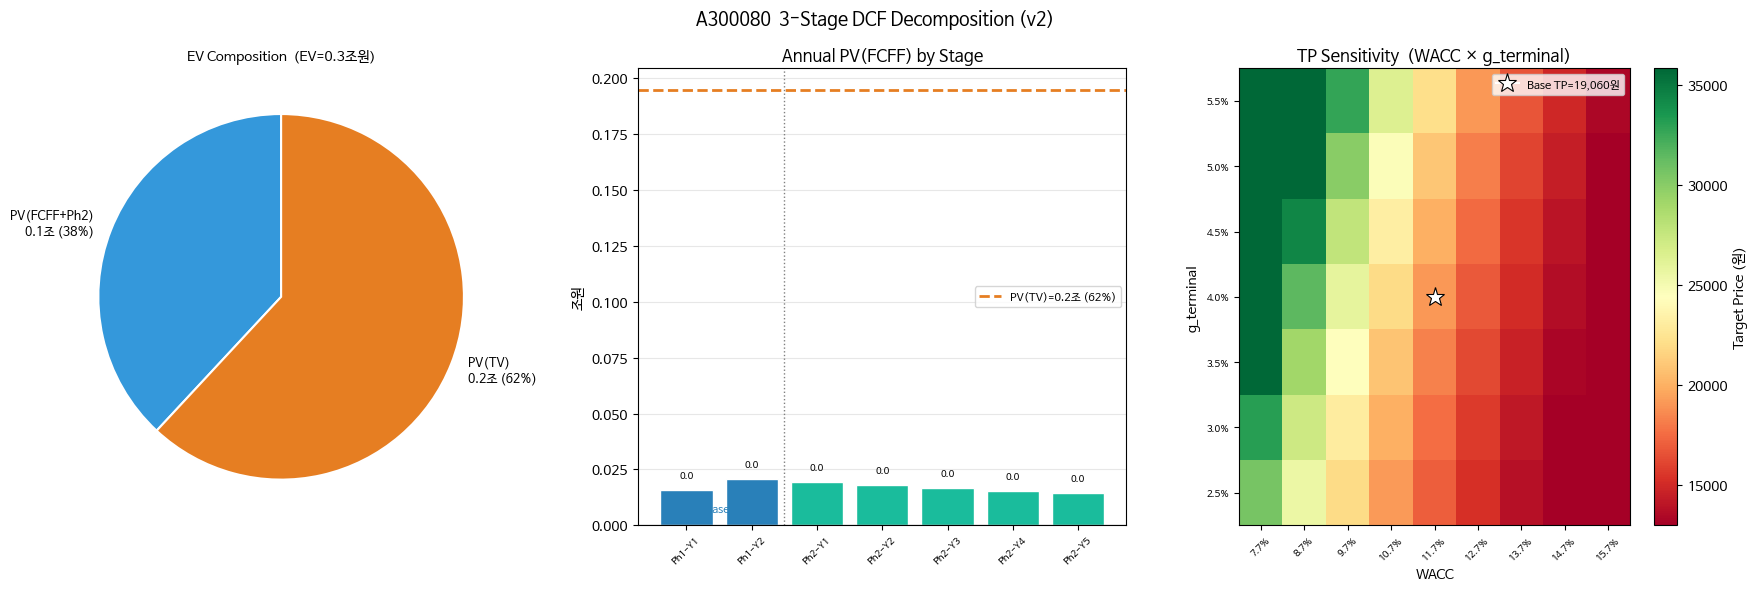

[Moat Analysis]
    ROIC (TTM)    : 226.19%
    WACC          : 11.69%
    EVA spread    : +214.50%
    Moat grade    : No moat
    AR(1) ρ       : 0.500
    Phase2 period : 5 yr
    g₀ method     : min(12Q-TTM=4.0%, FC=46.6%) → 12Q-TTM


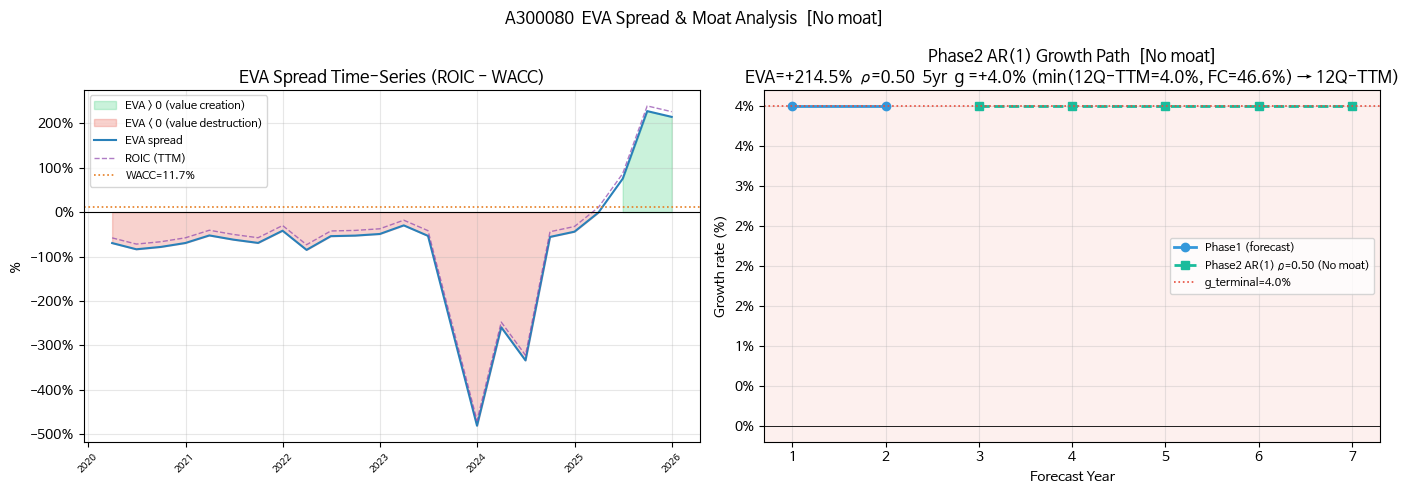

In [14]:
# ═══════════════════════════════════════════════════════════════
#  Cell 7 · 3-Stage DCF Decomposition & EVA Diagnostics
#  (US v11 Cell 4.5 한국화 — 단위: 조원, 통화: 원)
# ═══════════════════════════════════════════════════════════════

DIAG_TICKER = TEST_TICKER   # ★ 여기만 바꿔서 다른 종목 진단

print(f"[Diagnostics] Running KoreaDCFModel v2 for {DIAG_TICKER} ...")
_dm = KoreaDCFModel(ticker=DIAG_TICKER, engine=engine, db_info=db_info,
                    rf=RF, e_rm=E_RM, kospi_series=KOSPI_PX, verbose=True)
_dm.run()

v  = _dm.valuation
df = _dm.result_df.copy()
h  = _dm._fcff_history

wacc      = v["wacc"]
g_term    = v["g_terminal"]
ph1       = np.array(v["ph1_annual"])
ph2       = np.array(v["ph2_annual"])
g_ph2     = v["ph2_growth"]
all_ann   = np.array(v["all_annual"])
T_total   = v["t_total"]
fcff_last = v["fcff_last_annual"]
pv_fcff   = v["pv_fcff"]
tv        = v["terminal_value"]
pv_tv     = v["pv_tv"]
tv_wt     = v["tv_weight_pct"]
ev        = v["enterprise_value"]
net_debt  = v["net_debt"]
eq_val    = v["equity_value"]
shares    = v["shares"]
tp        = v["target_price"]
cp        = v["current_price"]

UNIT, UNIT_LBL = 1e12, "조"

SEP = "=" * 72
print(f"\n{SEP}")
print(f"  {DIAG_TICKER}  3-Stage DCF Decomposition (v2)")
print(SEP)

print(f"\n[1] Discount rate")
print(f"    WACC          : {wacc*100:.4f}%   (Re={v['wacc_re']*100:.2f}%, Rd={v['wacc_rd']*100:.2f}%, β={v['beta_blume']:.3f})")
print(f"    g_terminal    : {g_term*100:.4f}%")
print(f"    WACC - g      : {(wacc-g_term)*100:.4f}%")

print(f"\n[2] Phase 1 — Forecast FCFF (Year 1~{len(ph1)})")
cum = 0.0
for t, f in enumerate(ph1, 1):
    pv = f / (1+wacc)**t; cum += pv
    q0 = df["quarter"].iloc[(t-1)*4] if (t-1)*4 < len(df) else "?"
    q1 = df["quarter"].iloc[min(t*4-1, len(df)-1)]
    print(f"    Year {t} ({q0}~{q1})  FCFF={f/UNIT:>8.3f}{UNIT_LBL}  "
          f"PV={pv/UNIT:>8.3f}{UNIT_LBL}  Cum={cum/UNIT:>8.3f}{UNIT_LBL}")

print(f"\n[3] Phase 2 — Growth convergence (Year {len(ph1)+1}~{len(ph1)+len(ph2)})")
print(f"    g₀ method   : {v.get('g0_method','?')}    g₀={v.get('g0',np.nan)*100:+.1f}%")
print(f"      (hist={('%+.1f%%'%(v.get('g0_hist')*100)) if v.get('g0_hist') is not None else 'N/A'},  "
      f"fc={('%+.1f%%'%(v.get('g0_fc')*100)) if v.get('g0_fc') is not None else 'N/A'})")
print(f"    AR(1) ρ     : {v.get('moat_rho',np.nan):.3f}    Phase2 기간: {v.get('n_phase2',0)}년")
for t_off, (f, g) in enumerate(zip(ph2, g_ph2), 1):
    yr = len(ph1) + t_off
    pv = f / (1+wacc)**yr; cum += pv
    print(f"    Year {yr:>2}  g={g*100:>+5.1f}%  FCFF={f/UNIT:>8.3f}{UNIT_LBL}  "
          f"PV={pv/UNIT:>8.3f}{UNIT_LBL}  Cum={cum/UNIT:>8.3f}{UNIT_LBL}")

print(f"\n[4] Phase 3 — Terminal Value")
print(f"    Last annual FCFF : {fcff_last/UNIT:.3f}{UNIT_LBL}원")
print(f"    TV = {fcff_last/UNIT:.3f}{UNIT_LBL} × {1+g_term:.4f} / {wacc-g_term:.4f}"
      f" = {tv/UNIT:.3f}{UNIT_LBL}원")
print(f"    PV(TV) = TV / (1+WACC)^{T_total} = {pv_tv/UNIT:.3f}{UNIT_LBL}원")

fcff_wt = pv_fcff / ev * 100 if ev != 0 else float("nan")
print(f"\n[5] EV Breakdown")
print(f"    PV(Phase1+2 FCFF) = {pv_fcff/UNIT:.3f}{UNIT_LBL}원  ({fcff_wt:.1f}%)")
print(f"    PV(TV)            = {pv_tv/UNIT:.3f}{UNIT_LBL}원  ({tv_wt:.1f}%)")
print(f"    Enterprise Value  = {ev/UNIT:.3f}{UNIT_LBL}원")

print(f"\n[6] Equity Bridge")
print(f"    EV {ev/UNIT:.3f}{UNIT_LBL}원  -  Net Debt {net_debt/UNIT:.3f}{UNIT_LBL}원  "
      f"=  Equity {eq_val/UNIT:.3f}{UNIT_LBL}원")
tp_str = f"{tp:,.0f}원" if not np.isnan(tp) else "N/A"
cp_str = f"{cp:,.0f}원" if cp else "N/A"
up_str = (f"{v['upside_pct']:+.1f}%"
          if not np.isnan(v.get('upside_pct', float('nan'))) else "N/A")
print(f"    / {shares/1e6:.1f}M shares  =  TP {tp_str}  (Current {cp_str}, Upside {up_str})")

print(f"\n{SEP}\n")

# ════════════════════════════════════════════════════════════════
#  시각화 (1 x 3) : EV pie / Annual PV / WACC×g sensitivity
# ════════════════════════════════════════════════════════════════
_ev_positive = ev > 0 and pv_fcff > 0 and pv_tv > 0

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(f"{DIAG_TICKER}  3-Stage DCF Decomposition (v2)",
             fontsize=13, fontweight="bold")

# ── A: EV composition pie ────────────────────────────────────────
ax = axes[0]
if _ev_positive:
    ax.pie(
        [pv_fcff, pv_tv],
        labels=[f"PV(FCFF+Ph2)\n{pv_fcff/UNIT:.1f}{UNIT_LBL} ({fcff_wt:.0f}%)",
                f"PV(TV)\n{pv_tv/UNIT:.1f}{UNIT_LBL} ({tv_wt:.0f}%)"],
        colors=["#3498db", "#e67e22"],
        startangle=90,
        wedgeprops=dict(edgecolor="white", linewidth=1.5),
        textprops=dict(fontsize=9),
    )
    ax.set_title(f"EV Composition  (EV={ev/UNIT:.1f}{UNIT_LBL}원)", fontsize=10)
else:
    ax.axis("off")
    msg  = f"EV = {ev/UNIT:.1f}{UNIT_LBL}원\n"
    msg += f"PV(FCFF) = {pv_fcff/UNIT:.1f}{UNIT_LBL}원\n"
    msg += f"PV(TV)   = {pv_tv/UNIT:.1f}{UNIT_LBL}원\n\n"
    msg += "Negative EV: pie chart\nnot applicable."
    ax.text(0.5, 0.5, msg, transform=ax.transAxes,
            ha="center", va="center", fontsize=10,
            bbox=dict(boxstyle="round,pad=0.6", facecolor="#ffeeba", alpha=0.9))
    ax.set_title("EV Composition  (negative — chart skipped)", fontsize=10)

# ── B: Annual PV(FCFF) bar + PV(TV) line ────────────────────────
ax = axes[1]
yr_labels  = ([f"Ph1-Y{i+1}" for i in range(len(ph1))]
              + [f"Ph2-Y{i+1}" for i in range(len(ph2))])
pv_yr      = [f / (1+wacc)**(t+1) for t, f in enumerate(all_ann)]
colors_yr  = (["#2980b9"] * len(ph1)) + (["#1abc9c"] * len(ph2))

ax.bar(yr_labels, [v_ / UNIT for v_ in pv_yr], color=colors_yr, edgecolor="white")
ax.axhline(pv_tv / UNIT, color="#e67e22", lw=2.0, ls="--",
           label=f"PV(TV)={pv_tv/UNIT:.1f}{UNIT_LBL} ({tv_wt:.0f}%)")
ax.axvline(len(ph1) - 0.5, color="gray", lw=1, ls=":")

_ylim = ax.get_ylim()
_y_txt = _ylim[0] + (_ylim[1] - _ylim[0]) * 0.03
ax.text(len(ph1)/2 - 0.5, _y_txt, "Phase 1", ha="center", fontsize=8, color="#2980b9")
ax.text(len(ph1) + len(ph2)/2 - 0.5, _y_txt, "Phase 2", ha="center", fontsize=8, color="#1abc9c")

for i, val in enumerate(pv_yr):
    offset = abs(_ylim[1] - _ylim[0]) * 0.02
    va = "bottom" if val >= 0 else "top"
    y_pos = val/UNIT + (offset if val >= 0 else -offset)
    ax.text(i, y_pos, f"{val/UNIT:.1f}", ha="center", va=va, fontsize=7)

ax.axhline(0, color="black", lw=0.8)
ax.set_title("Annual PV(FCFF) by Stage")
ax.set_ylabel(f"{UNIT_LBL}원")
ax.tick_params(axis="x", rotation=45, labelsize=7)
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)

# ── C: WACC × g sensitivity heatmap ─────────────────────────────
ax = axes[2]
wacc_range = np.arange(max(wacc - 0.04, 0.04), wacc + 0.045, 0.01)
g_range    = np.arange(max(g_term - 0.015, 0.0), g_term + 0.020, 0.005)

tp_mat = np.full((len(g_range), len(wacc_range)), np.nan)
for ri, g_ in enumerate(g_range):
    for ci, w_ in enumerate(wacc_range):
        if w_ - g_ < 0.005:
            continue
        pv_f = sum(all_ann[t] / (1+w_)**(t+1) for t in range(T_total))
        tv_  = fcff_last * (1+g_) / (w_ - g_)
        ev_  = pv_f + tv_ / (1+w_)**T_total
        if shares and shares > 0 and not np.isnan(shares):
            tp_mat[ri, ci] = (ev_ - net_debt) / shares

_valid = tp_mat[~np.isnan(tp_mat)]
if len(_valid) > 0:
    im = ax.imshow(tp_mat, aspect="auto", cmap="RdYlGn",
                   vmin=np.nanpercentile(tp_mat, 10),
                   vmax=np.nanpercentile(tp_mat, 90),
                   origin="lower")
    plt.colorbar(im, ax=ax, label="Target Price (원)")
    ax.set_xticks(range(len(wacc_range)))
    ax.set_xticklabels([f"{w*100:.1f}%" for w in wacc_range], rotation=45, fontsize=7)
    ax.set_yticks(range(len(g_range)))
    ax.set_yticklabels([f"{g_*100:.1f}%" for g_ in g_range], fontsize=7)
    ax.set_xlabel("WACC")
    ax.set_ylabel("g_terminal")
    ax.set_title("TP Sensitivity  (WACC × g_terminal)")
    ci_cur = np.argmin(np.abs(wacc_range - wacc))
    ri_cur = np.argmin(np.abs(g_range - g_term))
    tp_str2 = f"{tp:,.0f}원" if not np.isnan(tp) else "N/A"
    ax.plot(ci_cur, ri_cur, marker="*", ms=14, color="white",
            markeredgecolor="black", markeredgewidth=0.8,
            label=f"Base TP={tp_str2}")
    ax.legend(fontsize=8)
else:
    ax.axis("off")
    ax.text(0.5, 0.5, "All TP values invalid\n(negative FCFF / EV)",
            transform=ax.transAxes, ha="center", va="center", fontsize=11,
            bbox=dict(boxstyle="round,pad=0.6", facecolor="#ffeeba", alpha=0.9))
    ax.set_title("TP Sensitivity  (skipped)")

plt.tight_layout()
plt.show()

# ════════════════════════════════════════════════════════════════
#  EVA spread time-series + Moat diagnostics
# ════════════════════════════════════════════════════════════════
eva_series = v.get("eva_series", [])
moat_label = v.get("moat_label", "N/A")
eva_spread = v.get("eva_spread", np.nan)
roic_val   = v.get("roic", np.nan)
moat_rho   = v.get("moat_rho", np.nan)
n_ph2      = v.get("n_phase2", 0)

print("[Moat Analysis]")
print(f"    ROIC (TTM)    : {roic_val*100:.2f}%" if not np.isnan(roic_val) else "    ROIC      : N/A")
print(f"    WACC          : {wacc*100:.2f}%")
print(f"    EVA spread    : {eva_spread*100:+.2f}%" if not np.isnan(eva_spread) else "    EVA spread : N/A")
print(f"    Moat grade    : {moat_label}")
print(f"    AR(1) ρ       : {moat_rho:.3f}" if not np.isnan(moat_rho) else "    ρ         : N/A")
print(f"    Phase2 period : {n_ph2} yr")
print(f"    g₀ method     : {v.get('g0_method','?')}")

if eva_series:
    fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))
    fig2.suptitle(f"{DIAG_TICKER}  EVA Spread & Moat Analysis  [{moat_label}]",
                  fontsize=12, fontweight="bold")

    # ── EVA spread time-series ────────────────────────────────────
    ax = axes2[0]
    dates_e = [e["date"] for e in eva_series]
    spreads = [e["eva_spread"] * 100 for e in eva_series]
    roics   = [e["roic"]       * 100 for e in eva_series]

    ax.fill_between(dates_e, spreads, 0,
                    where=[s > 0 for s in spreads],
                    color="#2ecc71", alpha=0.25, label="EVA > 0 (value creation)")
    ax.fill_between(dates_e, spreads, 0,
                    where=[s <= 0 for s in spreads],
                    color="#e74c3c", alpha=0.25, label="EVA < 0 (value destruction)")
    ax.plot(dates_e, spreads, color="#2980b9", lw=1.5, label="EVA spread")
    ax.plot(dates_e, roics,   color="#8e44ad", lw=1.0, ls="--", alpha=0.7, label="ROIC (TTM)")
    ax.axhline(0,           color="black",   lw=0.8)
    ax.axhline(wacc * 100,  color="#e67e22", lw=1.2, ls=":", label=f"WACC={wacc*100:.1f}%")
    ax.set_title("EVA Spread Time-Series (ROIC - WACC)")
    ax.set_ylabel("%")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))
    ax.tick_params(axis="x", rotation=45, labelsize=7)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    # ── Moat grade + AR(1) growth path ───────────────────────────
    ax = axes2[1]
    _g0 = v.get("g0", np.nan)
    if np.isnan(_g0):
        _g0 = (ph2[0] / ph1[-1] - 1) if (len(ph1) > 0 and ph1[-1] != 0 and len(ph2) > 0) else 0.05
    yrs_ph2 = list(range(3, 3 + n_ph2))
    ph2_pct = [g * 100 for g in g_ph2[:n_ph2]] if len(g_ph2) >= n_ph2 else [_g0 * 100] * n_ph2

    ax.plot([1, 2], [_g0 * 100, _g0 * 100],
            "o-", color="#3498db", lw=2, label="Phase1 (forecast)")
    if yrs_ph2 and ph2_pct:
        ax.plot(yrs_ph2, ph2_pct, "s--", color="#1abc9c", lw=2,
                label=(f"Phase2 AR(1) ρ={moat_rho:.2f} ({moat_label})"
                       if not np.isnan(moat_rho) else "Phase2"))
    ax.axhline(GDP_GROWTH * 100, color="#e74c3c", lw=1.2, ls=":",
               label=f"g_terminal={GDP_GROWTH*100:.1f}%")
    ax.axhline(0, color="black", lw=0.6)

    moat_colors = {"Wide moat":   "#27ae60", "Narrow moat": "#2980b9",
                   "Some moat":   "#f39c12", "No moat":     "#e74c3c"}
    ax.set_facecolor(moat_colors.get(moat_label, "#95a5a6") + "15")

    eva_str = f"{eva_spread*100:+.1f}%" if not np.isnan(eva_spread) else "N/A"
    rho_str = f"{moat_rho:.2f}"         if not np.isnan(moat_rho)   else "N/A"
    ax.set_title(f"Phase2 AR(1) Growth Path  [{moat_label}]\n"
                 f"EVA={eva_str}  ρ={rho_str}  {n_ph2}yr  g₀={_g0*100:+.1f}% ({v.get('g0_method','?')})")
    ax.set_xlabel("Forecast Year")
    ax.set_ylabel("Growth rate (%)")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("  [No EVA series — insufficient IS/BS data]")



  Sensitivity Analysis: A300080
[메모리] forecast_sarima 실행 전: 536.29 MB
[메모리] find_best_sarima_params 실행 전: 536.29 MB
[메모리] find_best_sarima_params 실행 후: 533.63 MB (변화: -2.65 MB)
[메모리] forecast_sarima 실행 후: 533.63 MB (변화: -2.65 MB)
[메모리] forecast_ets 실행 전: 533.63 MB
[메모리] forecast_ets 실행 후: 533.63 MB (변화: +0.00 MB)
[메모리] forecast_theta 실행 전: 533.63 MB
[메모리] forecast_theta 실행 후: 533.63 MB (변화: +0.00 MB)
  Base  WACC=11.69%  g=4.00%  TP=19,060원  Moat=No moat  Phase2=5yr


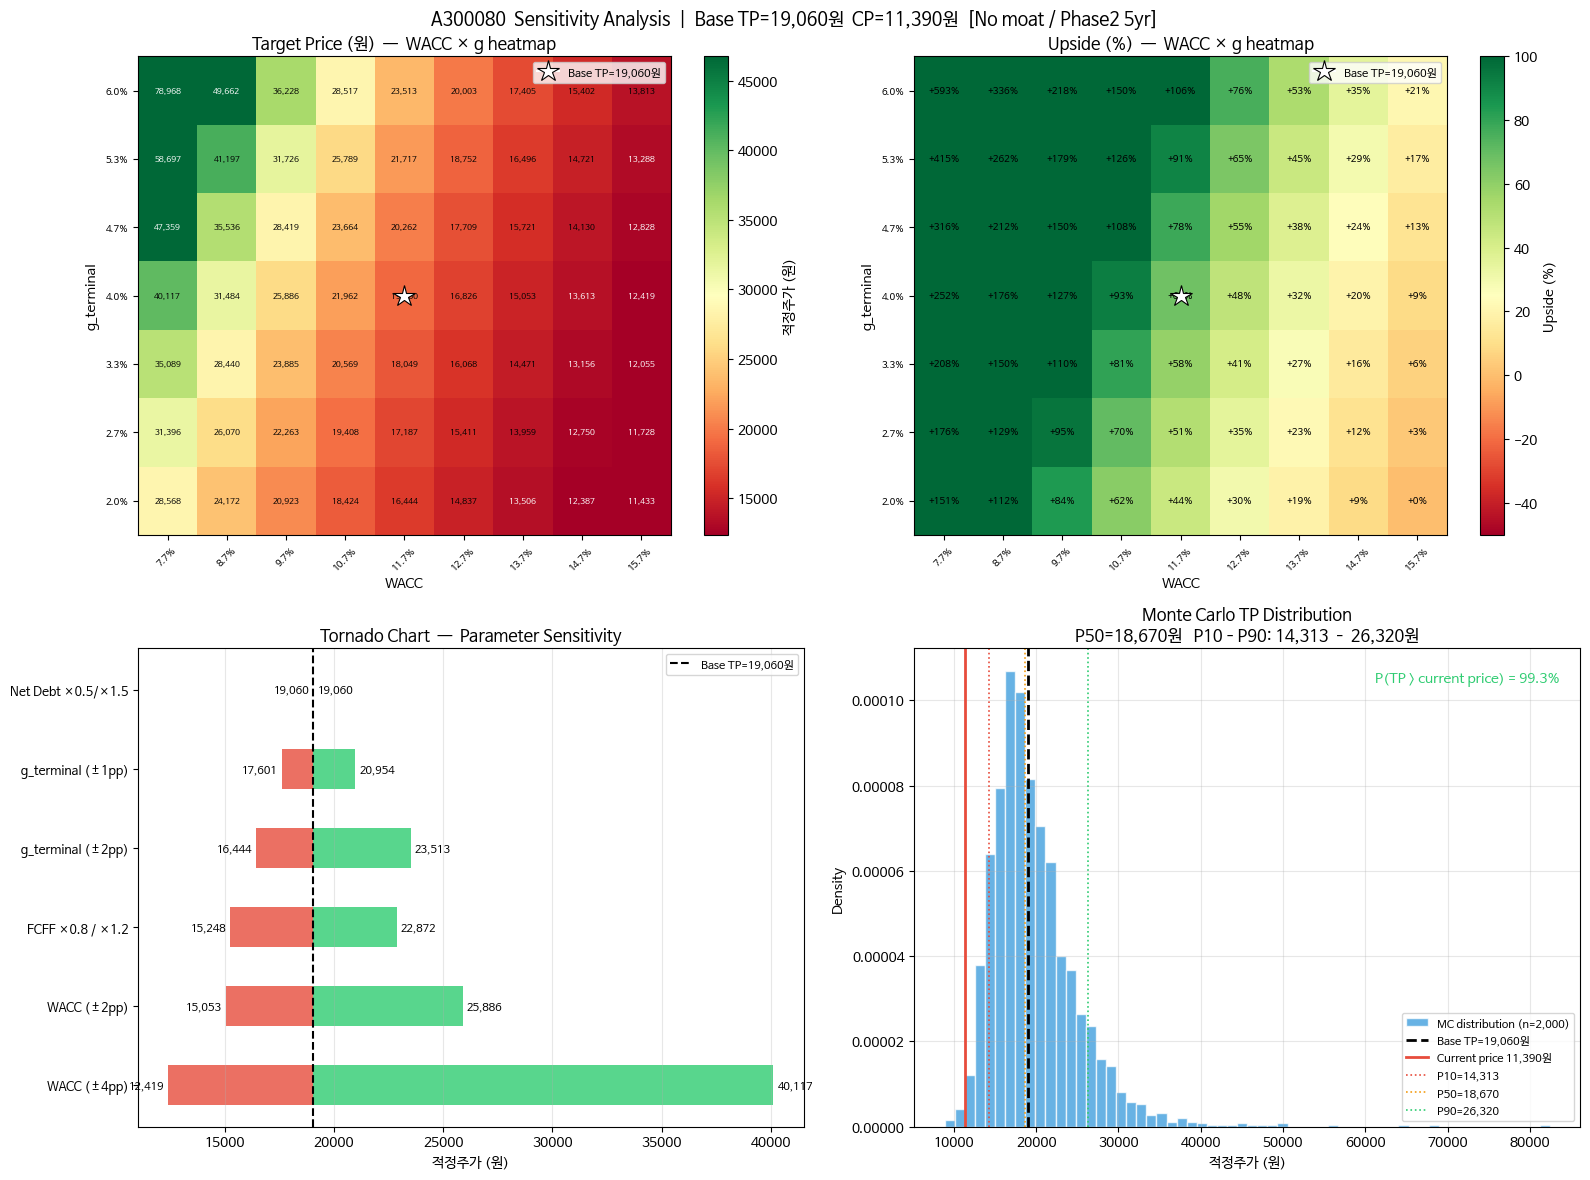


  [TP Range Summary]
    Heatmap range   : 11,433원 – 78,968원
    MC P10/P50/P90  : 14,313 / 18,670 / 26,320원
    P(TP > cur price): 99.3%
    Most sensitive  : WACC (±4pp)  (12,419 – 40,117원)


In [15]:
# ═══════════════════════════════════════════════════════════════
#  Cell 8 · Sensitivity Analysis (★ 단일 종목 진단)
#  ─ 2D heatmap : WACC × g_terminal  →  Target Price / Upside %
#  ─ Tornado chart : single-param sweep  →  TP range
#  ─ Monte Carlo   : input uncertainty  →  TP distribution
#
#  Cell 7 (Decomposition), Cell 9 (단일 Excel) 와 동일하게 1종목 진단 패턴.
#  배치는 Cell 10 에서 별도로 수행.
#
#  미국 모형과의 차이:
#    - 통화 단위: $ → 원
#    - 종목코드: A-prefix 한국 ticker
# ═══════════════════════════════════════════════════════════════

# ── 분석할 ticker (★ 변경 시 이 줄만 수정) ──────────────────
SENS_TICKER = TEST_TICKER   # Cell 5 의 TEST_TICKER (default: A005930 삼성전자)
# 다른 종목으로 분석하려면 SENS_TICKER = "A000660"  같이 직접 지정 가능
# ════════════════════════════════════════════════════════════

# ── Parameter ranges ─────────────────────────────────────────────
WACC_STEPS  = 9     # WACC grid points
G_STEPS     = 7     # g_terminal grid points
WACC_DELTA  = 0.04  # base WACC ± 4 pp
G_DELTA     = 0.02  # base g    ± 2 pp
MC_RUNS     = 2000  # Monte Carlo iterations

# ── Fast scalar DCF helper ────────────────────────────────────────
def _dcf_tp_kr(all_annual, fcff_last, net_debt, shares, wacc, g):
    """연도별 FCFF 배열 + 파라미터 → 적정주가 (스칼라, 원 단위)"""
    if wacc - g < 0.005 or shares <= 0:
        return np.nan
    pv_f  = sum(all_annual[t] / (1 + wacc) ** (t + 1)
                for t in range(len(all_annual)))
    tv    = fcff_last * (1 + g) / (wacc - g)
    pv_tv = tv / (1 + wacc) ** len(all_annual)
    return max((pv_f + pv_tv - net_debt) / shares, 0)


def _fmt_won(x):
    """원 → 가독성 있는 표기 (조/억)"""
    if np.isnan(x):
        return "N/A"
    ax = abs(x)
    if ax >= 1e12:
        return f"{x/1e12:,.1f}조"
    elif ax >= 1e8:
        return f"{x/1e8:,.0f}억"
    else:
        return f"{x:,.0f}"


# ════════════════════════════════════════════════════════════════
#  단일 종목 실행
# ════════════════════════════════════════════════════════════════

print(f"\n{'='*64}")
print(f"  Sensitivity Analysis: {SENS_TICKER}")
print(f"{'='*64}")

_m = KoreaDCFModel(
    ticker=SENS_TICKER, engine=engine,
    db_info=db_info, rf=RF, e_rm=E_RM, kospi_series=KOSPI_PX,
    verbose=False,
)
_m.run()

v          = _m.valuation
wacc_base  = v["wacc"]
g_base     = v["g_terminal"]
all_annual = np.array(v["all_annual"])
fcff_last  = v["fcff_last_annual"]
net_debt   = v["net_debt"]
shares     = v["shares"]
tp_base    = v["target_price"]
cp         = v["current_price"]
moat_lbl   = v.get("moat_label", "N/A")
n_ph2      = v.get("n_phase2",  0)

assert not np.isnan(tp_base) and shares > 0, \
    f"[{SENS_TICKER}] TP 산출 불가 — Cell 7 Decomposition 으로 원인 진단 필요"

print(f"  Base  WACC={wacc_base*100:.2f}%  g={g_base*100:.2f}%  "
      f"TP={tp_base:,.0f}원  Moat={moat_lbl}  Phase2={n_ph2}yr")

# ════════════════════════════════════════════════════════════
# 1) 2-D heatmaps  (TP  &  Upside %)
# ════════════════════════════════════════════════════════════
wacc_arr = np.linspace(max(wacc_base - WACC_DELTA, 0.04),
                       wacc_base + WACC_DELTA, WACC_STEPS)
g_arr    = np.linspace(max(g_base - G_DELTA, 0.00),
                       min(g_base + G_DELTA, 0.08), G_STEPS)

tp_mat     = np.full((len(g_arr), len(wacc_arr)), np.nan)
upside_mat = np.full_like(tp_mat, np.nan)

for ri, g_ in enumerate(g_arr):
    for ci, w_ in enumerate(wacc_arr):
        tp_ = _dcf_tp_kr(all_annual, fcff_last, net_debt, shares, w_, g_)
        if tp_ is not None and not np.isnan(tp_):
            tp_mat[ri, ci] = tp_
            if cp > 0:
                upside_mat[ri, ci] = (tp_ / cp - 1) * 100

# ════════════════════════════════════════════════════════════
# 2) Tornado chart
# ════════════════════════════════════════════════════════════
tornado_params = {
    "WACC (±4pp)":       ("wacc", wacc_base - 0.04, wacc_base + 0.04),
    "g_terminal (±2pp)": ("g",    max(g_base - 0.02, 0.005), g_base + 0.02),
    "WACC (±2pp)":       ("wacc", wacc_base - 0.02, wacc_base + 0.02),
    "g_terminal (±1pp)": ("g",    max(g_base - 0.01, 0.005), g_base + 0.01),
    "FCFF ×0.8 / ×1.2":  ("fcff", 0.80, 1.20),
    "Net Debt ×0.5/×1.5":("debt", 0.50, 1.50),
}

tornado_data = []
for label, (ptype, lo, hi) in tornado_params.items():
    if ptype == "wacc":
        tp_lo = _dcf_tp_kr(all_annual, fcff_last, net_debt, shares, lo, g_base)
        tp_hi = _dcf_tp_kr(all_annual, fcff_last, net_debt, shares, hi, g_base)
    elif ptype == "g":
        tp_lo = _dcf_tp_kr(all_annual, fcff_last, net_debt, shares, wacc_base, lo)
        tp_hi = _dcf_tp_kr(all_annual, fcff_last, net_debt, shares, wacc_base, hi)
    elif ptype == "fcff":
        tp_lo = _dcf_tp_kr(all_annual * lo, fcff_last * lo, net_debt, shares, wacc_base, g_base)
        tp_hi = _dcf_tp_kr(all_annual * hi, fcff_last * hi, net_debt, shares, wacc_base, g_base)
    elif ptype == "debt":
        tp_lo = _dcf_tp_kr(all_annual, fcff_last, net_debt * hi, shares, wacc_base, g_base)
        tp_hi = _dcf_tp_kr(all_annual, fcff_last, net_debt * lo, shares, wacc_base, g_base)
    else:
        continue
    if tp_lo is not None and tp_hi is not None:
        tornado_data.append((label, tp_lo, tp_hi))

tornado_data.sort(key=lambda x: abs(x[2] - x[1]), reverse=True)

# ════════════════════════════════════════════════════════════
# 3) Monte Carlo
# ════════════════════════════════════════════════════════════
np.random.seed(42)
mc_wacc   = np.random.normal(wacc_base, 0.015, MC_RUNS)
mc_g      = np.random.normal(g_base,    0.008, MC_RUNS)
mc_fcff_s = np.random.normal(1.0,       0.10,  MC_RUNS)

mc_tp = []
for w_, g_, fs_ in zip(mc_wacc, mc_g, mc_fcff_s):
    if w_ - g_ < 0.005 or w_ < 0.02:
        continue
    tp_ = _dcf_tp_kr(all_annual * fs_, fcff_last * fs_, net_debt, shares, w_, g_)
    if tp_ is not None and not np.isnan(tp_) and 0 < tp_ < tp_base * 10:
        mc_tp.append(tp_)
mc_tp = np.array(mc_tp)

# ════════════════════════════════════════════════════════════
# Visualisation (2x2)
# ════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(
    f"{SENS_TICKER}  Sensitivity Analysis  |  "
    f"Base TP={tp_base:,.0f}원  CP={cp:,.0f}원  "
    f"[{moat_lbl} / Phase2 {n_ph2}yr]",
    fontsize=13, fontweight="bold"
)

# ── (1) Target Price heatmap ──────────────────────────────────
ax = axes[0, 0]
vmin = np.nanpercentile(tp_mat, 5)
vmax = np.nanpercentile(tp_mat, 95)
im = ax.imshow(tp_mat, aspect="auto", cmap="RdYlGn",
               vmin=vmin, vmax=vmax, origin="lower")
plt.colorbar(im, ax=ax, label="적정주가 (원)")

ci_b = np.argmin(np.abs(wacc_arr - wacc_base))
ri_b = np.argmin(np.abs(g_arr    - g_base))
ax.plot(ci_b, ri_b, marker="*", ms=16, color="white",
        markeredgecolor="black", markeredgewidth=0.8, zorder=5,
        label=f"Base TP={tp_base:,.0f}원")

for ri in range(len(g_arr)):
    for ci in range(len(wacc_arr)):
        val = tp_mat[ri, ci]
        if not np.isnan(val):
            txt_col = "white" if (val < vmin * 1.1 or val > vmax * 0.9) else "black"
            ax.text(ci, ri, f"{val:,.0f}", ha="center", va="center",
                    fontsize=6, color=txt_col)

ax.set_xticks(range(len(wacc_arr)))
ax.set_xticklabels([f"{w*100:.1f}%" for w in wacc_arr], rotation=45, fontsize=7)
ax.set_yticks(range(len(g_arr)))
ax.set_yticklabels([f"{g*100:.1f}%" for g in g_arr], fontsize=7)
ax.set_xlabel("WACC")
ax.set_ylabel("g_terminal")
ax.set_title("Target Price (원)  —  WACC × g heatmap")
ax.legend(fontsize=8, loc="upper right")

# ── (2) Upside % heatmap ──────────────────────────────────────
ax = axes[0, 1]
im2 = ax.imshow(upside_mat, aspect="auto", cmap="RdYlGn",
                vmin=-50, vmax=100, origin="lower")
plt.colorbar(im2, ax=ax, label="Upside (%)")
ax.plot(ci_b, ri_b, marker="*", ms=16, color="white",
        markeredgecolor="black", markeredgewidth=0.8, zorder=5,
        label=f"Base TP={tp_base:,.0f}원")

for ri in range(len(g_arr)):
    for ci in range(len(wacc_arr)):
        val = upside_mat[ri, ci]
        if not np.isnan(val):
            ax.text(ci, ri, f"{val:+.0f}%", ha="center", va="center",
                    fontsize=7, color="black")

ax.set_xticks(range(len(wacc_arr)))
ax.set_xticklabels([f"{w*100:.1f}%" for w in wacc_arr], rotation=45, fontsize=7)
ax.set_yticks(range(len(g_arr)))
ax.set_yticklabels([f"{g*100:.1f}%" for g in g_arr], fontsize=7)
ax.set_xlabel("WACC")
ax.set_ylabel("g_terminal")
ax.set_title("Upside (%)  —  WACC × g heatmap")
ax.legend(fontsize=8, loc="upper right")

# ── (3) Tornado chart ─────────────────────────────────────────
ax = axes[1, 0]
labels  = [t[0] for t in tornado_data]
lo_vals = [t[1] for t in tornado_data]
hi_vals = [t[2] for t in tornado_data]
y_pos   = range(len(labels))

for y, lo, hi in zip(y_pos, lo_vals, hi_vals):
    if lo < hi:
        ax.barh(y, hi - tp_base, left=tp_base,
                color="#2ecc71", alpha=0.8, height=0.5)
        ax.barh(y, lo - tp_base, left=tp_base,
                color="#e74c3c", alpha=0.8, height=0.5)
    else:
        ax.barh(y, lo - tp_base, left=tp_base,
                color="#2ecc71", alpha=0.8, height=0.5)
        ax.barh(y, hi - tp_base, left=tp_base,
                color="#e74c3c", alpha=0.8, height=0.5)
    ax.text(max(lo, hi) + tp_base * 0.01, y,
            f"{max(lo, hi):,.0f}", va="center", fontsize=8)
    ax.text(min(lo, hi) - tp_base * 0.01, y,
            f"{min(lo, hi):,.0f}", va="center", ha="right", fontsize=8)

ax.axvline(tp_base, color="black", lw=1.5, ls="--",
           label=f"Base TP={tp_base:,.0f}원")
ax.set_yticks(list(y_pos))
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel("적정주가 (원)")
ax.set_title("Tornado Chart  —  Parameter Sensitivity")
ax.legend(fontsize=8)
ax.grid(axis="x", alpha=0.3)

# ── (4) Monte Carlo distribution ─────────────────────────────
ax = axes[1, 1]
if len(mc_tp) > 100:
    ax.hist(mc_tp, bins=60, color="#3498db", edgecolor="white",
            alpha=0.75, density=True,
            label=f"MC distribution (n={len(mc_tp):,})")
    ax.axvline(tp_base, color="black", lw=2.0, ls="--",
               label=f"Base TP={tp_base:,.0f}원")
    if not np.isnan(cp):
        ax.axvline(cp, color="#e74c3c", lw=2.0,
                   label=f"Current price {cp:,.0f}원")

    p10, p25, p50, p75, p90 = np.percentile(mc_tp, [10, 25, 50, 75, 90])
    for pval, plbl, col in [
        (p10, "P10", "#e74c3c"),
        (p50, "P50", "#f39c12"),
        (p90, "P90", "#2ecc71"),
    ]:
        ax.axvline(pval, color=col, lw=1.2, ls=":",
                   label=f"{plbl}={pval:,.0f}")

    if not np.isnan(cp) and cp > 0:
        prob_up = (mc_tp > cp).mean() * 100
        ax.text(0.97, 0.95,
                f"P(TP > current price) = {prob_up:.1f}%",
                transform=ax.transAxes, ha="right", va="top",
                fontsize=10, fontweight="bold",
                color="#2ecc71" if prob_up > 50 else "#e74c3c")

    ax.set_title(
        f"Monte Carlo TP Distribution\n"
        f"P50={p50:,.0f}원   P10–P90: {p10:,.0f} – {p90:,.0f}원"
    )
else:
    ax.text(0.5, 0.5, "Insufficient MC data",
            transform=ax.transAxes, ha="center", va="center", fontsize=12)
    ax.set_title("Monte Carlo TP Distribution")

ax.set_xlabel("적정주가 (원)")
ax.set_ylabel("Density")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ── Summary text ─────────────────────────────────────────────
print(f"\n  [TP Range Summary]")
print(f"    Heatmap range   : {np.nanmin(tp_mat):,.0f}원 – {np.nanmax(tp_mat):,.0f}원")
if len(mc_tp) > 100:
    print(f"    MC P10/P50/P90  : {p10:,.0f} / {p50:,.0f} / {p90:,.0f}원")
    if not np.isnan(cp) and cp > 0:
        print(f"    P(TP > cur price): {prob_up:.1f}%")
print(f"    Most sensitive  : {tornado_data[0][0]}  "
      f"({min(tornado_data[0][1], tornado_data[0][2]):,.0f}"
      f" – {max(tornado_data[0][1], tornado_data[0][2]):,.0f}원)")


In [16]:
# ═══════════════════════════════════════════════════════════════
#  Cell 9 (★ NEW v2)  ·  단일 Ticker → 즉시 Excel 출력
# ═══════════════════════════════════════════════════════════════
#  Cell 6 의 패치를 적용한 후 실행.
#  전체 배치 없이 단일 종목만 빠르게 9-sheet Excel 생성.
# ═══════════════════════════════════════════════════════════════

# ── 분석할 ticker 입력 (★ 변경 시 이 줄만 수정) ───────────
EXPORT_TICKER = TEST_TICKER   # 삼성전자
# ════════════════════════════════════════════════════════════

# ── 출력 경로 (자동 분기) ─────────────────────────────────
EXPORT_DIR = (Path(r"C:/reports") if os.name == "nt"
              else Path.home() / "reports")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

print(f"\n{'='*70}")
print(f"[Single Export] {EXPORT_TICKER} → 9-sheet Excel (한국화 v2)")
print(f"{'='*70}")

# ── 사전 검증 ────────────────────────────────────────────
assert hasattr(KoreaDCFModel, "export_korea_excel"), \
    "KoreaDCFModel.export_korea_excel 없음 — Cell 6 패치 셀을 먼저 실행하세요."

# ── 실행 ─────────────────────────────────────────────────
_model = KoreaDCFModel(
    ticker=EXPORT_TICKER, engine=engine,
    db_info=db_info, rf=RF, e_rm=E_RM, kospi_series=KOSPI_PX,
    verbose=True,
)
try:
    _model.run()
    _path = _model.export_korea_excel(out_dir=EXPORT_DIR)
    v = _model.valuation
    print(f"\n  ✓ Saved: {_path}")
    tp_str = f"{v['target_price']:,.0f}원" if not np.isnan(v['target_price']) else "N/A"
    cp_str = f"{v['current_price']:,.0f}원" if v['current_price'] else "N/A"
    up_str = f"{v['upside_pct']:+.1f}%" if not np.isnan(v['upside_pct']) else "N/A"
    print(f"    적정주가     : {tp_str}")
    print(f"    현재 주가    : {cp_str}")
    print(f"    Upside       : {up_str}")
    print(f"    WACC         : {v['wacc']*100:.2f}%")
    print(f"    g_terminal   : {v['g_terminal']*100:.2f}%")
    print(f"    Moat         : {v['moat_label']}  "
          f"(ρ={v['moat_rho']:.3f}, Phase2={v['n_phase2']}년)")
    print(f"    g₀ method    : {v.get('g0_method', 'n/a')}")
except Exception as e:
    print(f"\n  ✗ FAIL: {e}")
    import traceback
    traceback.print_exc()



[Single Export] A300080 → 9-sheet Excel (한국화 v2)
[09:33:13][A300080] Sales actual=27Q forecast=8Q model=Ensemble created_at=2026-04-21 00:00:00
[09:33:14][A300080] ⚠️  NWC 필드가 전부 0: inventories (inventories)
[09:33:14][A300080] FS wide  shape=(67, 35)  기간=2009-12-31 ~ 2026-06-30
[메모리] forecast_sarima 실행 전: 543.91 MB
[메모리] find_best_sarima_params 실행 전: 543.91 MB
[메모리] find_best_sarima_params 실행 후: 532.78 MB (변화: -11.12 MB)
[메모리] forecast_sarima 실행 후: 532.78 MB (변화: -11.12 MB)
[메모리] forecast_ets 실행 전: 532.78 MB
[메모리] forecast_ets 실행 후: 532.78 MB (변화: +0.00 MB)
[메모리] forecast_theta 실행 전: 532.78 MB
[메모리] forecast_theta 실행 후: 532.78 MB (변화: +0.00 MB)
[09:33:19][A300080] [NWC seed] γ×sales=3.0B vs 실측=0.0B 괴리 301106364628.5%
[09:33:22][A300080] β_raw=1.158 β_blume=1.106  Re=11.6920%  (n=1667, R²=0.06)
[09:33:26][A300080] WACC=11.6920%  Re=11.6920% Rd=5.0452% tax=0.0090%  E/V=100.00% D/V=0.00%  E=0.19조 D=0.00조
[09:33:26][A300080] EVA: ROIC=226.19%  WACC=11.69%  spread=+214.50%  n_pos(20Q)=3/2

In [17]:
# ─────────────────────────────────────────────────────────────
#  Cell 10 · 배치 실행 (v2)
#  - v1 동작 그대로 유지
#  - process_one_ticker_kr() 내부에서 v8/v9.2 패치된 KoreaDCFModel 사용
# ─────────────────────────────────────────────────────────────

RUN_TICKERS = KOREA_TICKER_LIST[TICKER_START:TICKER_END]
total = len(RUN_TICKERS)
run_date = datetime.now().strftime("%Y-%m-%d")

done_set = set()
if SKIP_DONE and os.path.exists(DONE_PATH):
    with open(DONE_PATH, encoding="utf-8") as f:
        done_set = {l.strip() for l in f if l.strip()}

ok_cnt = skip_cnt = fail_cnt = 0
results = []
all_reports = []
t0 = time.time()

log("BATCH", f"배치 시작 (v2): {total:,}개  run_date={run_date}  SKIP_DONE={SKIP_DONE}")
print("=" * 80)

for idx, ticker in enumerate(RUN_TICKERS, 1):
    pct = idx / total * 100
    prefix = f"[{idx:>5}/{total}] ({pct:5.1f}%) {ticker:<8}"

    if SKIP_DONE and ticker in done_set:
        print(f"{prefix} SKIP", flush=True); skip_cnt += 1; continue

    res = process_one_ticker_kr(
        ticker, engine, db_info, RF, E_RM, KOSPI_PX,
        verbose=False, run_date=run_date, save_db=True,
    )
    results.append(res)
    if res["report"] is not None:
        all_reports.append(res["report"])

    if res["status"] == "ok":
        tp = res["target_price"]; up = res["upside_pct"]; w = res["wacc"]
        tp_s = f"TP={tp:,.0f}원" if not np.isnan(tp) else "TP=N/A"
        up_s = f"↑{up:+.1f}%" if not np.isnan(up) else ""
        print(f"{prefix} OK  {tp_s} {up_s}  WACC={w:.3%}  Moat={res['moat']}", flush=True)
        with open(DONE_PATH, "a", encoding="utf-8") as f:
            f.write(ticker + "\n")
        ok_cnt += 1
    else:
        print(f"{prefix} FAIL  {res['msg']}", flush=True)
        with open(FAIL_PATH, "a", encoding="utf-8") as f:
            f.write(f"{ticker}\t{res['msg']}\n")
        fail_cnt += 1

elapsed = time.time() - t0
print("=" * 80)
log("BATCH", f"완료  OK={ok_cnt}  SKIP={skip_cnt}  FAIL={fail_cnt}  "
             f"경과={elapsed:.0f}s  평균={elapsed/max(ok_cnt+fail_cnt,1):.1f}s/ticker")

# ── 데이터 품질 리포트 DB 저장 ────────────────────────────────
if all_reports:
    n_quality = save_quality_report_to_db(
        all_reports, db_info, table_name=TABLE_QUALITY,
        run_date=run_date, model_name="FCFF_DCF",
    )
    log("QUALITY", f"데이터 품질 로그 저장: {n_quality:,}건 → {TABLE_QUALITY}")

# ── 결과 요약 ────────────────────────────────────────────────
if results:
    summary = pd.DataFrame([{
        "ticker": r["ticker"], "target_price": r["target_price"],
        "current_price": r["current_price"], "upside_pct": r["upside_pct"],
        "wacc": r["wacc"], "g_terminal": r["g_terminal"], "moat": r["moat"],
        "status": r["status"],
    } for r in results])
    ok_summary = summary[summary["status"] == "ok"].sort_values(
        "upside_pct", ascending=False)
    print("\n[상위 업사이드 종목 TOP 20]")
    display(ok_summary.head(20))


[09:33:30][BATCH] 배치 시작 (v2): 1,267개  run_date=2026-05-12  SKIP_DONE=False
[메모리] forecast_sarima 실행 전: 532.80 MB
[메모리] find_best_sarima_params 실행 전: 532.80 MB


KeyboardInterrupt: 

In [ ]:
# ─────────────────────────────────────────────────────────────
#  Cell 11 · 결과 조회 & 시각화 (v2 — v1 동일)
# ─────────────────────────────────────────────────────────────

# ── 8-1. DB 현황 (날짜별 평가 기록) ─────────────────────────
conn = get_pymysql_conn(db_info)
try:
    with conn.cursor() as cur:
        cur.execute(f"""
            SELECT DATE(date) AS run_date,
                   COUNT(DISTINCT ticker) AS tickers,
                   COUNT(*) AS total_rows,
                   AVG(target_price) AS avg_tp,
                   AVG(upside_pct) AS avg_upside,
                   AVG(discount_rate) AS avg_wacc
            FROM {TABLE_RESULT}
            GROUP BY DATE(date)
            ORDER BY run_date DESC LIMIT 10
        """)
        _summary = pd.DataFrame(cur.fetchall())
finally:
    conn.close()

print("=" * 70)
print(f"[DB 현황] {TABLE_RESULT}")
print("=" * 70)
display(_summary)

# ── 8-2. 최신 평가일 기준 업사이드 분포 ─────────────────────
conn = get_pymysql_conn(db_info)
try:
    with conn.cursor() as cur:
        cur.execute(f"SELECT MAX(date) AS m FROM {TABLE_RESULT}")
        max_date = cur.fetchone()["m"]
        if max_date:
            cur.execute(f"""
                SELECT ticker,
                       MAX(target_price) AS target_price,
                       MAX(current_price) AS current_price,
                       MAX(upside_pct) AS upside_pct,
                       MAX(discount_rate) AS wacc,
                       MAX(g_terminal) AS g_terminal,
                       MAX(moat_label) AS moat
                FROM {TABLE_RESULT}
                WHERE date=%s AND target_price IS NOT NULL AND current_price IS NOT NULL
                GROUP BY ticker
                ORDER BY upside_pct DESC
            """, (max_date,))
            results_df = pd.DataFrame(cur.fetchall())
        else:
            results_df = pd.DataFrame()
finally:
    conn.close()

if max_date and not results_df.empty:
    print(f"\n[최신 평가일: {max_date}] 총 {len(results_df)}개")
    print("\n🔼 업사이드 TOP 20")
    display(results_df.head(20))
    print("\n🔽 다운사이드 TOP 20")
    display(results_df.tail(20))

    # 분포 시각화
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Korea Valuation Summary v2 ({max_date})", fontsize=13)
    ax = axes[0]
    upside_clean = results_df["upside_pct"].dropna().clip(-200, 200)
    ax.hist(upside_clean, bins=40, color="#3498db", edgecolor="white", alpha=0.8)
    ax.axvline(0, color="black", lw=1)
    ax.axvline(20, color="green", lw=1, ls="--", label="+20% (Buy zone)")
    ax.set_title("Upside Distribution")
    ax.set_xlabel("Upside (%)"); ax.legend(); ax.grid(alpha=0.3)

    ax = axes[1]
    grade = pd.cut(results_df["upside_pct"],
                   bins=[-np.inf, -20, 0, 20, 50, np.inf],
                   labels=["Strong Sell", "Sell", "Hold", "Buy", "Strong Buy"])
    grade.value_counts().sort_index().plot(
        kind="barh", ax=ax,
        color=["#c0392b", "#e74c3c", "#f39c12", "#2ecc71", "#27ae60"])
    ax.set_title("Valuation Grade"); ax.grid(axis="x", alpha=0.3)
    plt.tight_layout(); plt.show()
else:
    print("[INFO] 데이터 없음 — Cell 10 배치 실행 필요")

# ── 8-3. 종목별 평가일자 추이 ───────────────────────────────
print("\n[종목별 평가 이력 예시 — 삼성전자]")
hist = get_evaluation_history("A005930", db_info, table_name=TABLE_RESULT)
display(hist)


## Cell 12 · 데이터 품질 진단

배치 실행 시 `us_data_quality_log` (한국 모형은 동일 테이블 사용 가정)에 누적된 품질 로그를 분석.

### 조회 항목
1. **항목별 status 분포** — `ok / fallback_median / fallback_zero / missing` 비율
2. **fallback 비율 TOP** — 어떤 항목이 회귀 fallback에 자주 의존하는지
3. **문제 종목 TOP 30** — fallback + missing 합계가 3 이상인 종목

### 활용
- `inspect_ticker_quality("A005930")` 헬퍼로 종목별 상세 진단 조회 가능
- v2의 NWC sanity check가 `note` 필드에 어떤 alias로 매핑되었는지 기록


In [ ]:
# ─────────────────────────────────────────────────────────────
#  Cell 12 · 데이터 품질 진단 (v2 — v1 동일)
# ─────────────────────────────────────────────────────────────

conn = get_pymysql_conn(db_info)
try:
    with conn.cursor() as cur:
        # 1) 최신 평가일의 status별 분포
        cur.execute(f"""
            SELECT field, status, COUNT(*) AS cnt,
                   AVG(r_squared) AS avg_r2,
                   AVG(value) AS avg_value
            FROM {TABLE_QUALITY}
            WHERE date = (SELECT MAX(date) FROM {TABLE_QUALITY} WHERE model='FCFF_DCF')
              AND model='FCFF_DCF'
            GROUP BY field, status
            ORDER BY field, status
        """)
        df_status = pd.DataFrame(cur.fetchall())

        # 2) fallback 비율 높은 항목 TOP 10
        cur.execute(f"""
            SELECT field,
                   SUM(status='ok') AS ok_cnt,
                   SUM(status='fallback_median') AS fb_med,
                   SUM(status='fallback_zero') AS fb_zero,
                   SUM(status='missing') AS miss,
                   COUNT(*) AS total,
                   ROUND(SUM(status LIKE 'fallback%')/COUNT(*)*100, 1) AS fb_pct
            FROM {TABLE_QUALITY}
            WHERE date = (SELECT MAX(date) FROM {TABLE_QUALITY} WHERE model='FCFF_DCF')
              AND model='FCFF_DCF'
            GROUP BY field
            ORDER BY fb_pct DESC
        """)
        df_field = pd.DataFrame(cur.fetchall())

        # 3) 가장 문제 많은 종목 TOP 30
        cur.execute(f"""
            SELECT ticker,
                   SUM(status LIKE 'fallback%') AS fallback_cnt,
                   SUM(status='missing') AS miss_cnt,
                   GROUP_CONCAT(DISTINCT field ORDER BY field SEPARATOR ',') AS issues
            FROM {TABLE_QUALITY}
            WHERE date = (SELECT MAX(date) FROM {TABLE_QUALITY} WHERE model='FCFF_DCF')
              AND model='FCFF_DCF'
              AND (status LIKE 'fallback%' OR status='missing')
            GROUP BY ticker
            HAVING fallback_cnt + miss_cnt >= 3
            ORDER BY (fallback_cnt + miss_cnt*2) DESC
            LIMIT 30
        """)
        df_problem_tickers = pd.DataFrame(cur.fetchall())
finally:
    conn.close()

print("=" * 70); print("[1] 항목별 status 분포 (최신 평가일)"); print("=" * 70)
display(df_status)

print("\n" + "=" * 70); print("[2] 항목별 fallback 비율 (TOP)"); print("=" * 70)
display(df_field)

print("\n" + "=" * 70); print("[3] 데이터 문제가 많은 종목 TOP 30 (수동 확인 권장)"); print("=" * 70)
display(df_problem_tickers)

# ── 4) 특정 종목의 모든 진단 항목 조회 함수 ──────────────
def inspect_ticker_quality(ticker: str, run_date: str = None) -> pd.DataFrame:
    """특정 종목의 데이터 품질 상세 (해당 평가일 또는 최신)."""
    tk = to_dg_ticker(ticker)
    conn = get_pymysql_conn(db_info)
    try:
        with conn.cursor() as cur:
            if run_date:
                cur.execute(f"""SELECT date, field, status, n_obs, value, r_squared, note
                                  FROM {TABLE_QUALITY}
                                  WHERE ticker=%s AND date=%s AND model='FCFF_DCF'
                                  ORDER BY field""", (tk, run_date))
            else:
                cur.execute(f"""SELECT date, field, status, n_obs, value, r_squared, note
                                  FROM {TABLE_QUALITY}
                                  WHERE ticker=%s AND model='FCFF_DCF'
                                    AND date = (SELECT MAX(date) FROM {TABLE_QUALITY}
                                                 WHERE ticker=%s AND model='FCFF_DCF')
                                  ORDER BY field""", (tk, tk))
            return pd.DataFrame(cur.fetchall())
    finally:
        conn.close()

# 사용 예시
print("\n[예시] 삼성전자 데이터 품질 상세")
display(inspect_ticker_quality("A005930"))
